# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from scipy.linalg import null_space, eigh



In [2]:
# Environment versions used for this analysis
import sklearn, numpy, scipy
print('=== Library Versions ===')
print(f'sklearn: {sklearn.__version__}')
print(f'numpy:   {numpy.__version__}')
print(f'scipy:   {scipy.__version__}')
print()
print('Note: results may differ across environments due to library version')
print('differences. All results in the report were produced using the')
print('versions above on Google Colab.')

=== Library Versions ===
sklearn: 1.6.1
numpy:   2.0.2
scipy:   1.16.3

Note: results may differ across environments due to library version
differences. All results in the report were produced using the
versions above on Google Colab.


# Load data

In [3]:
url = "https://raw.githubusercontent.com/Algorithmic-Fairness-and-Ethics/Mitigating-gender-bias-in-german-gredit-risk-dataset/main/german_credit_data.csv"
df = pd.read_csv(url, sep=',')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


# Explonatary data analysis

In [4]:
df.nunique()

,0
Unnamed: 0,1000
Age,53
Sex,2
Job,4
Housing,3
Saving accounts,4
Checking account,3
Credit amount,921
Duration,33
Purpose,8


In [5]:
df.isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [6]:
df.dtypes

,0
Unnamed: 0,int64
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object


In [7]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


Description of the dataset:
  - Average age is ~35, with most people between 27 and 42 (min: 19, max: 75). Typical ages for people that want to start a family.
  - The average loan amount is ~3,271 DM, with most loans ranging between 1,365 and 3,972 DM (min: 250, max: 18,424).
  - Most people need 1 to 2 years to pay the requested loan, with an average of 1 year and 8 months (min: 4 months, max: 6 years)

In [8]:
df['Sex'].value_counts()

,count
Sex,
male,690
female,310


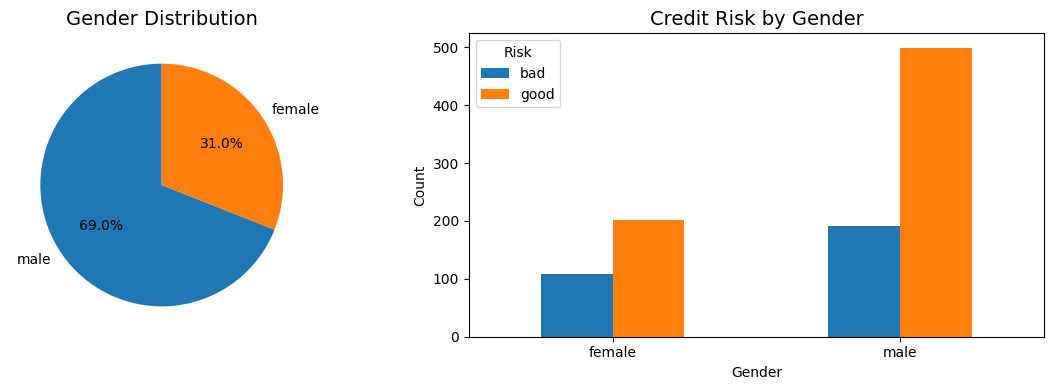

In [9]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df['Sex'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Gender Distribution', size=14)

# Risk by gender
risk_by_sex = df.groupby(['Sex', 'Risk']).size().unstack()
risk_by_sex.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Credit Risk by Gender', size=14)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].legend(title='Risk')

plt.tight_layout()
plt.show()

In [10]:
# Class imbalance check
risk_counts = df['Risk'].value_counts(normalize=True)
print('=== Class Distribution ===')
print(risk_counts)
print('\nThe dataset is imbalanced (70% good, 30% bad).')
print('We will use balanced accuracy to account for this.')

=== Class Distribution ===
Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

The dataset is imbalanced (70% good, 30% bad).
We will use balanced accuracy to account for this.


In [11]:
df = df.drop(columns=['Unnamed: 0'])

In [12]:
print(df.duplicated().sum())

0


In [13]:
print(df.isnull().sum())

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


In [14]:
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')

df['Checking account'] = df['Checking account'].fillna('unknown')

In [15]:
print(df.isnull().sum())

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


Sex distribution analysis

In [16]:
print(df['Sex'].value_counts())

Sex
male      690
female    310
Name: count, dtype: int64


In [17]:
sex_percent = df['Sex'].value_counts(normalize=True) * 100

print(sex_percent)

Sex
male      69.0
female    31.0
Name: proportion, dtype: float64


In [18]:
if abs(sex_percent.iloc[0] - sex_percent.iloc[1]) < 10:
    print("Dataset is balanced by sex.")
else:
    print("Dataset is imbalanced by sex.")

Dataset is imbalanced by sex.


Risk Analysis

In [19]:
df['Risk'].value_counts()

,count
Risk,
good,700
bad,300


In [20]:
df['Risk'].value_counts(normalize=True) * 100

,proportion
Risk,
good,70.0
bad,30.0


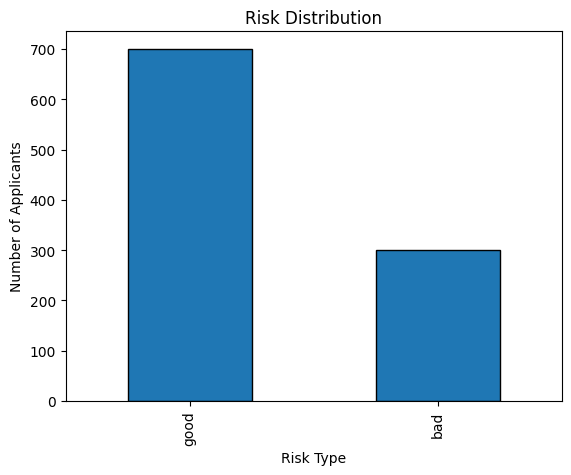

In [21]:
df['Risk'].value_counts().plot(kind='bar', edgecolor='black')

plt.title("Risk Distribution")
plt.xlabel("Risk Type")
plt.ylabel("Number of Applicants")
plt.show()

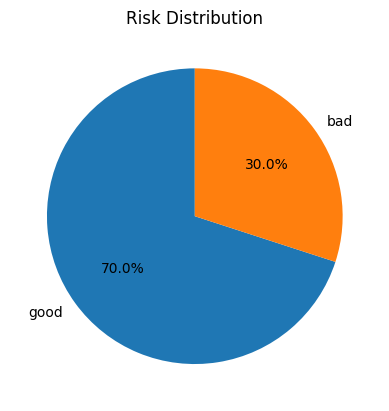

In [22]:
df['Risk'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Risk Distribution")
plt.ylabel("")
plt.show()

Sex vs Risk Analysis

In [23]:
sex_risk_table = pd.crosstab(df['Sex'], df['Risk'])

print(sex_risk_table)

Risk    bad  good
Sex              
female  109   201
male    191   499


In [24]:
sex_risk_percent = pd.crosstab(df['Sex'], df['Risk'], normalize='index') * 100

print(sex_risk_percent)

Risk          bad       good
Sex                         
female  35.161290  64.838710
male    27.681159  72.318841


In [25]:
bad_rate = sex_risk_percent['bad']

print(bad_rate)

Sex
female    35.161290
male      27.681159
Name: bad, dtype: float64


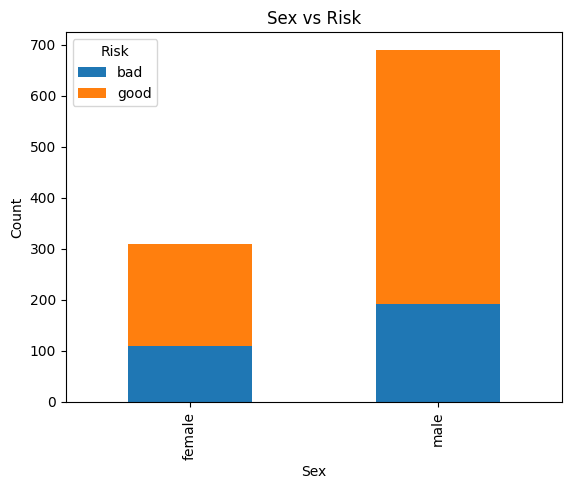

In [26]:
sex_risk_table.plot(kind='bar', stacked=True)

plt.title("Sex vs Risk")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.legend(title="Risk")
plt.show()

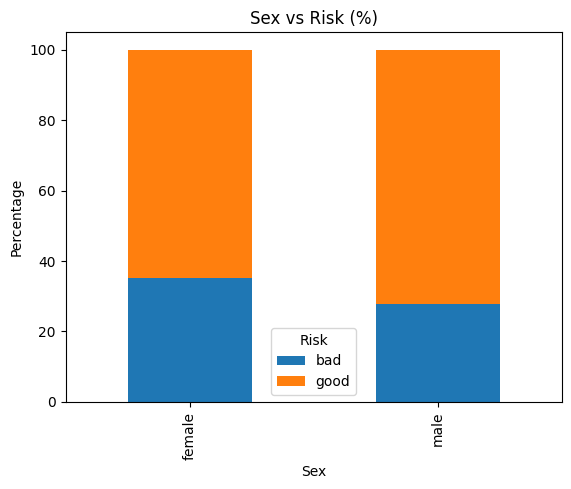

In [27]:
sex_risk_percent.plot(kind='bar', stacked=True)

plt.title("Sex vs Risk (%)")
plt.xlabel("Sex")
plt.ylabel("Percentage")

plt.legend(title="Risk")
plt.show()

In [28]:
male_bad = bad_rate['male']
female_bad = bad_rate['female']

print("Male bad rate:", male_bad)
print("Female bad rate:", female_bad)

if male_bad > female_bad:
    print("Males have higher bad risk rate.")
else:
    print("Females have higher bad risk rate.")

Male bad rate: 27.681159420289852
Female bad rate: 35.16129032258065
Females have higher bad risk rate.


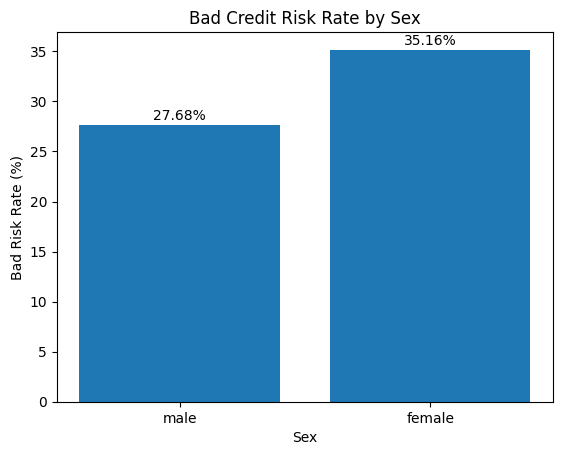

In [29]:
labels = ['male', 'female']
values = [male_bad, female_bad]

plt.bar(labels, values)


for i, v in enumerate(values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.title("Bad Credit Risk Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Bad Risk Rate (%)")

plt.show()

Average Age by Sex

In [30]:
print(df.groupby('Sex')['Age'].mean())

Sex
female    32.803226
male      36.778261
Name: Age, dtype: float64


In [31]:
# Max and minimum age by sex
print(df.groupby('Sex')['Age'].min())
print(df.groupby('Sex')['Age'].max())

Sex
female    19
male      20
Name: Age, dtype: int64
Sex
female    75
male      75
Name: Age, dtype: int64


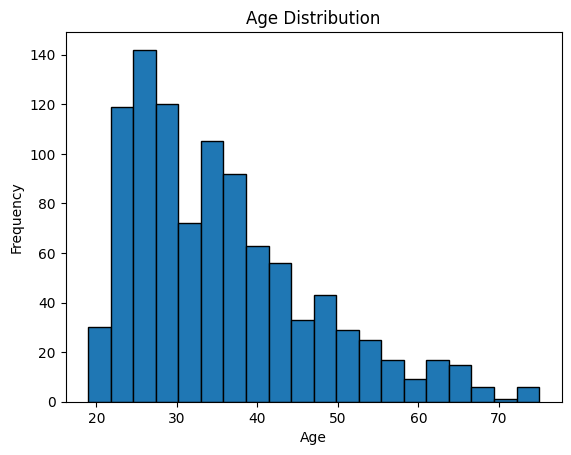

In [32]:
plt.hist(df['Age'], bins=20, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

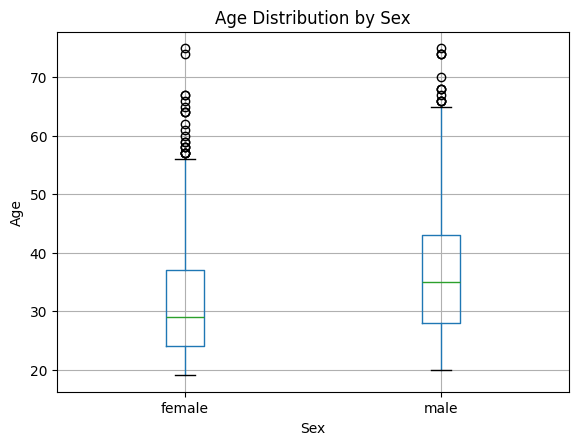

In [33]:
df.boxplot(column='Age', by='Sex')

plt.title("Age Distribution by Sex")
plt.suptitle("")
plt.xlabel("Sex")
plt.ylabel("Age")

plt.show()

Age, Sex and Risk Combined

In [34]:
df.groupby(['Sex', 'Risk'])['Age'].mean()

Sex     Risk
female  bad     30.009174
        good    34.318408
male    bad     36.219895
        good    36.991984
Name: Age, dtype: float64

In [35]:
df[df['Risk'] == 'bad'].groupby('Sex')['Age'].mean()

,Age
Sex,
female,30.009174
male,36.219895


In [36]:
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

In [37]:
pd.crosstab(df['Age_Group'], df['Risk'])

Risk,bad,good
Age_Group,,
18-25,80,110
26-35,118,280
36-45,55,171
46-60,37,104
60+,10,35


In [38]:
age_sex_risk = pd.crosstab([df['Age_Group'], df['Sex']], df['Risk'])
print(age_sex_risk)

Risk              bad  good
Age_Group Sex              
18-25     female   47    58
          male     33    52
26-35     female   45    72
          male     73   208
36-45     female    8    34
          male     47   137
46-60     female    8    27
          male     29    77
60+       female    1    10
          male      9    25


In [39]:
age_sex_risk_percent = pd.crosstab(
    [df['Age_Group'], df['Sex']],
    df['Risk'],
    normalize='index'
) * 100

print(age_sex_risk_percent)

Risk                    bad       good
Age_Group Sex                         
18-25     female  44.761905  55.238095
          male    38.823529  61.176471
26-35     female  38.461538  61.538462
          male    25.978648  74.021352
36-45     female  19.047619  80.952381
          male    25.543478  74.456522
46-60     female  22.857143  77.142857
          male    27.358491  72.641509
60+       female   9.090909  90.909091
          male    26.470588  73.529412


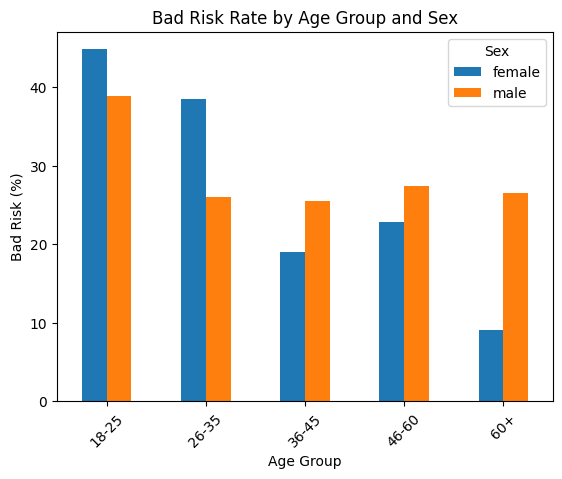

In [40]:
bad_risk = age_sex_risk_percent['bad'].unstack()

bad_risk.plot(kind='bar')

plt.title("Bad Risk Rate by Age Group and Sex")
plt.xlabel("Age Group")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=45)
plt.legend(title="Sex")

plt.show()

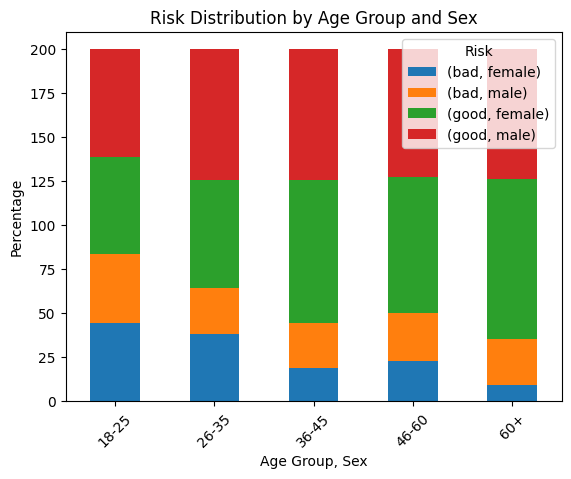

In [41]:
age_sex_risk_percent.unstack().plot(kind='bar', stacked=True)

plt.title("Risk Distribution by Age Group and Sex")
plt.xlabel("Age Group, Sex")
plt.ylabel("Percentage")

plt.xticks(rotation=45)
plt.legend(title="Risk")

plt.show()

Credit Amount Analysis by Sex

In [42]:
df.groupby('Sex')['Credit amount'].mean()

,Credit amount
Sex,
female,2877.774194
male,3448.040580


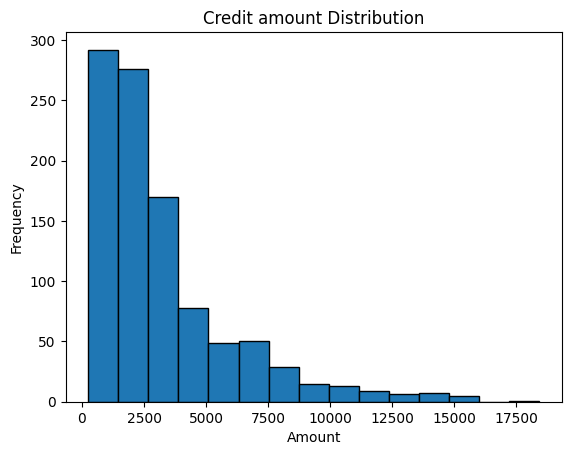

In [43]:
plt.hist(df['Credit amount'], bins=15, edgecolor='black')

plt.title("Credit amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [44]:
df.groupby('Sex')['Credit amount'].median()

,Credit amount
Sex,
female,1959.0
male,2443.5


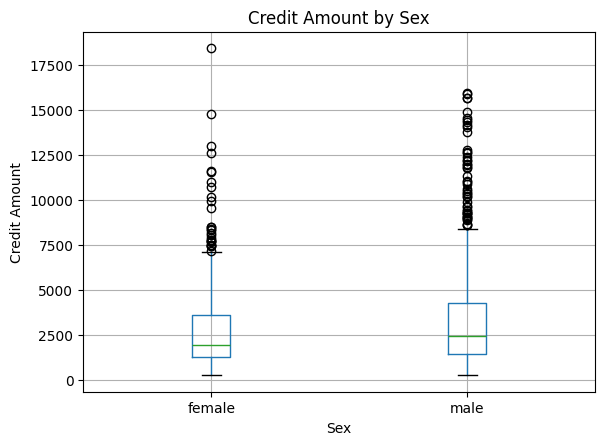

In [45]:
df.boxplot(column='Credit amount', by='Sex')

plt.title("Credit Amount by Sex")
plt.suptitle("")
plt.xlabel("Sex")
plt.ylabel("Credit Amount")

plt.show()

In [46]:
Q1 = df['Credit amount'].quantile(0.25)
Q3 = df['Credit amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Credit amount'] < lower_bound) | (df['Credit amount'] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 72


In [47]:
df.groupby(['Sex', 'Risk'])['Credit amount'].agg(['mean', 'median'])

mean  median
Sex    Risk                     
female bad   3471.183486  2039.0
       good  2555.975124  1927.0
male   bad   4204.602094  2820.0
       good  3158.454910  2346.0

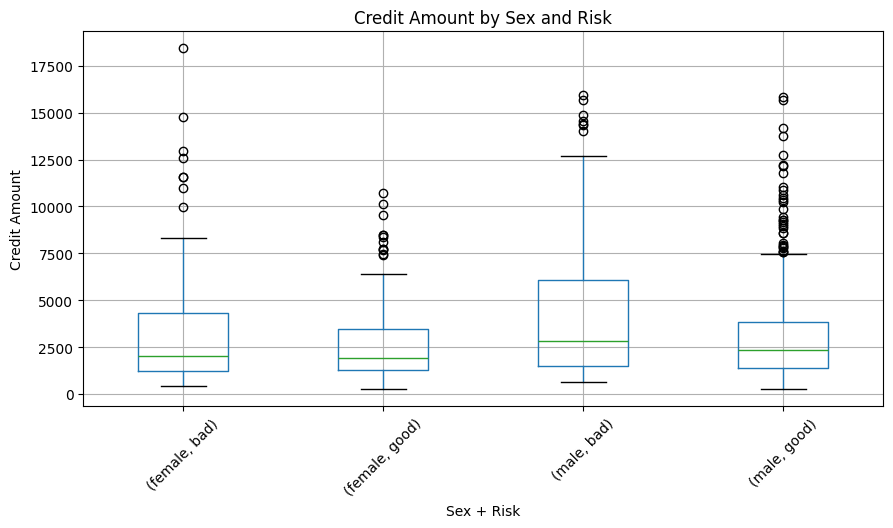

In [48]:
df.boxplot(column='Credit amount', by=['Sex', 'Risk'], figsize=(10,5))

plt.title("Credit Amount by Sex and Risk")
plt.suptitle("")
plt.xlabel("Sex + Risk")
plt.ylabel("Credit Amount")

plt.xticks(rotation=45)
plt.show()

Credit Amount, Sex and Risk

In [49]:
df[df['Sex'] == 'male'].groupby('Risk')['Credit amount'].mean()

,Credit amount
Risk,
bad,4204.602094
good,3158.454910


In [50]:
df[df['Sex'] == 'male'].groupby('Risk')['Credit amount'].median()

,Credit amount
Risk,
bad,2820.0
good,2346.0


In [51]:
df[df['Sex'] == 'female'].groupby('Risk')['Credit amount'].mean()

,Credit amount
Risk,
bad,3471.183486
good,2555.975124


In [52]:
df[df['Sex'] == 'female'].groupby('Risk')['Credit amount'].median()

,Credit amount
Risk,
bad,2039.0
good,1927.0


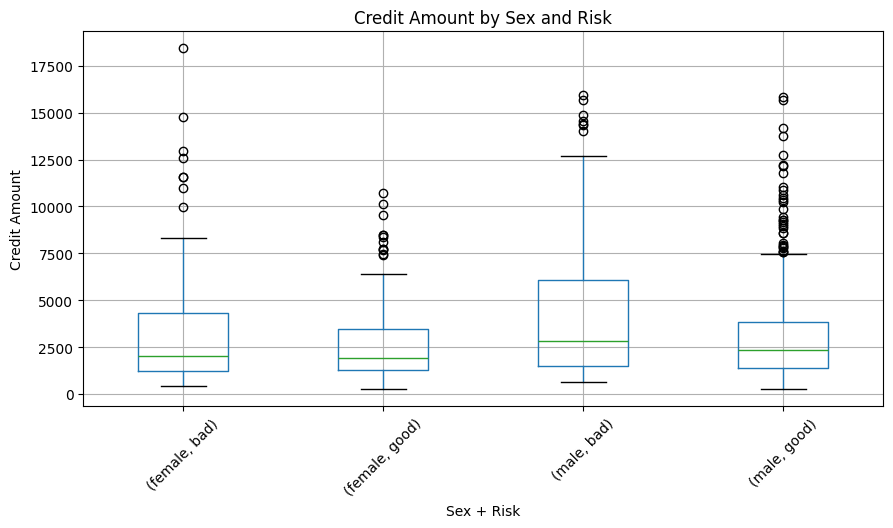

In [53]:
df.boxplot(column='Credit amount', by=['Sex', 'Risk'], figsize=(10,5))

plt.title("Credit Amount by Sex and Risk")
plt.suptitle("")
plt.xlabel("Sex + Risk")
plt.ylabel("Credit Amount")

plt.xticks(rotation=45)
plt.show()

In [54]:
bins = [0, 2500, 5000, 10000, df['Credit amount'].max()]
labels = ['Low', 'Medium', 'High', 'Very High']

df['Credit_Group'] = pd.cut(df['Credit amount'], bins=bins, labels=labels)

In [55]:
credit_risk = pd.crosstab(
    df['Credit_Group'],
    df['Risk'],
    normalize='index'
) * 100

print(credit_risk)

Risk                bad       good
Credit_Group                      
Low           27.374302  72.625698
Medium        27.272727  72.727273
High          36.486486  63.513514
Very High     60.000000  40.000000


In [56]:
bad_credit = credit_risk['bad']
print(bad_credit)

Credit_Group
Low          27.374302
Medium       27.272727
High         36.486486
Very High    60.000000
Name: bad, dtype: float64


In [57]:
credit_sex_risk = pd.crosstab(
    [df['Credit_Group'], df['Sex']],
    df['Risk'],
    normalize='index'
) * 100

print(credit_sex_risk)

Risk                       bad       good
Credit_Group Sex                         
Low          female  33.333333  66.666667
             male    24.216524  75.783476
Medium       female  27.848101  72.151899
             male    27.040816  72.959184
High         female  50.000000  50.000000
             male    32.142857  67.857143
Very High    female  77.777778  22.222222
             male    54.838710  45.161290


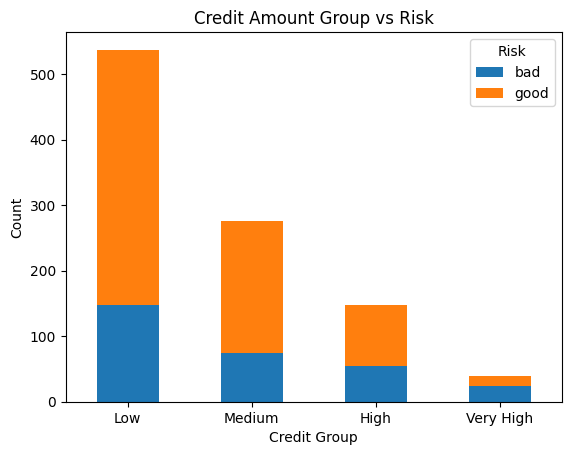

In [58]:
pd.crosstab(df['Credit_Group'], df['Risk']).plot(kind='bar', stacked=True)

plt.title("Credit Amount Group vs Risk")
plt.xlabel("Credit Group")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Risk")

plt.show()

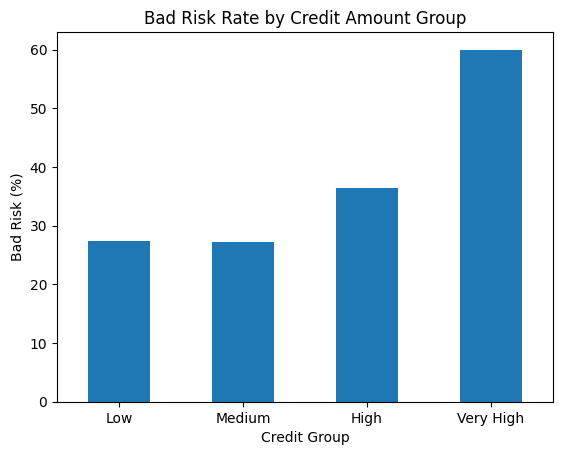

In [59]:
bad_credit.plot(kind='bar')

plt.title("Bad Risk Rate by Credit Amount Group")
plt.xlabel("Credit Group")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)

plt.show()

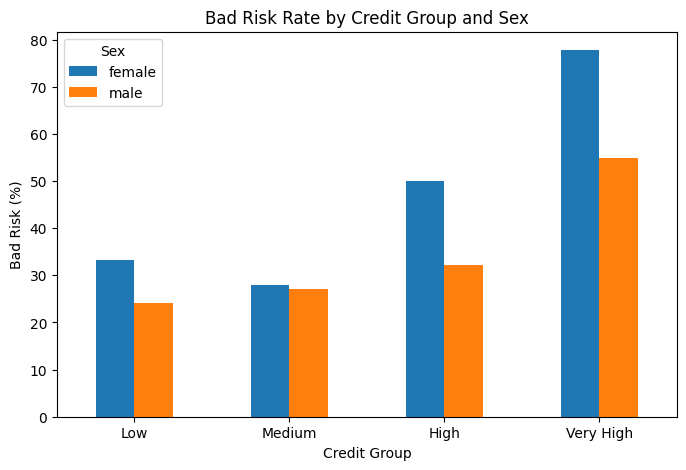

In [60]:
credit_sex_risk['bad'].unstack().plot(kind='bar', figsize=(8,5))

plt.title("Bad Risk Rate by Credit Group and Sex")
plt.xlabel("Credit Group")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.show()

Duration Analysis by Sex

In [61]:
df.groupby('Sex')['Duration'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Sex,,,,
female,19.43871,18.0,4,60
male,21.56087,18.0,4,72


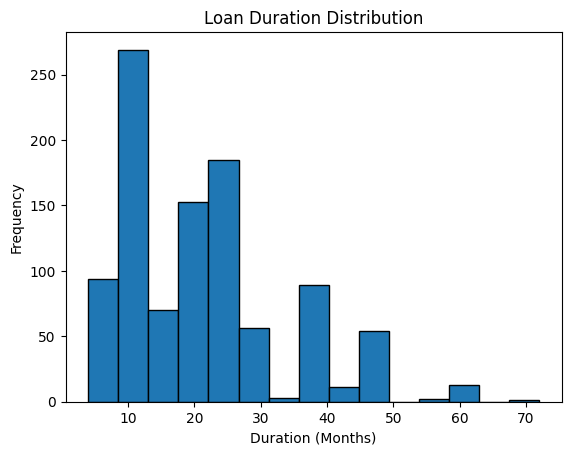

In [62]:
plt.hist(df['Duration'], bins=15, edgecolor='black')

plt.title("Loan Duration Distribution")
plt.xlabel("Duration (Months)")
plt.ylabel("Frequency")

plt.show()

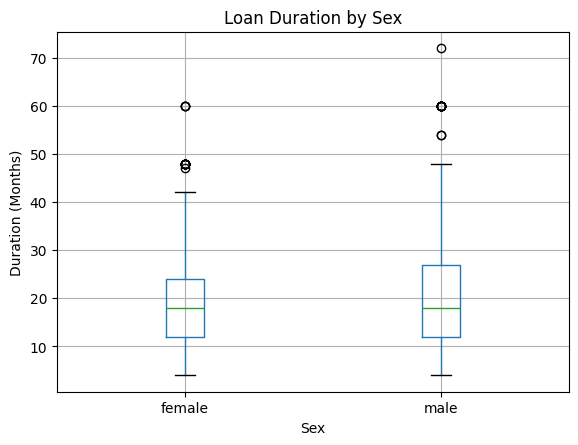

In [63]:
df.boxplot(column='Duration', by='Sex')

plt.title("Loan Duration by Sex")
plt.suptitle("")
plt.xlabel("Sex")
plt.ylabel("Duration (Months)")

plt.show()

In [64]:
duration_sex_risk = df.groupby(['Sex', 'Risk'])['Duration'].mean().unstack()

print(duration_sex_risk)

Risk          bad       good
Sex                         
female  22.926606  17.547264
male    25.963351  19.875752


In [65]:
bins = [0, 12, 24, 36, 48, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49+']

df['Duration_Group'] = pd.cut(df['Duration'], bins=bins, labels=labels)

In [66]:
duration_risk_percent = pd.crosstab(
    df['Duration_Group'],
    df['Risk'],
    normalize='index'
) * 100

print(duration_risk_percent)

Risk                  bad       good
Duration_Group                      
0-12            21.169916  78.830084
13-24           29.683698  70.316302
25-36           39.860140  60.139860
37-48           52.112676  47.887324
49+             50.000000  50.000000


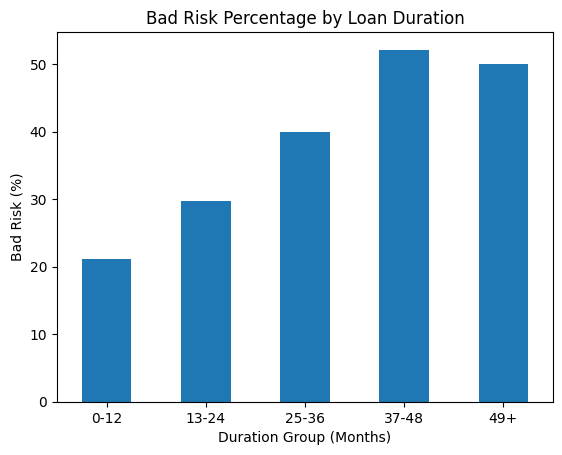

In [67]:
bad_duration = duration_risk_percent['bad']

bad_duration.plot(kind='bar')

plt.title("Bad Risk Percentage by Loan Duration")
plt.xlabel("Duration Group (Months)")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)
plt.show()

Duration, Sex and Risk

In [68]:
bins = [0, 12, 24, 100]
labels = ['Short-term (0–12)', 'Medium-term (13–24)', 'Long-term (25+)']

df['Duration_Group'] = pd.cut(df['Duration'], bins=bins, labels=labels)

In [69]:
duration_risk = pd.crosstab(df['Duration_Group'], df['Risk'])

print(duration_risk)

Risk                 bad  good
Duration_Group                
Short-term (0–12)     76   283
Medium-term (13–24)  122   289
Long-term (25+)      102   128


In [70]:
duration_risk_percent = pd.crosstab(
    df['Duration_Group'],
    df['Risk'],
    normalize='index'
) * 100

print(duration_risk_percent)

Risk                       bad       good
Duration_Group                           
Short-term (0–12)    21.169916  78.830084
Medium-term (13–24)  29.683698  70.316302
Long-term (25+)      44.347826  55.652174


In [71]:
sex_duration_risk = pd.crosstab(
    [df['Sex'], df['Duration_Group']],
    df['Risk']
)

print(sex_duration_risk)

Risk                        bad  good
Sex    Duration_Group                
female Short-term (0–12)     31    87
       Medium-term (13–24)   48    89
       Long-term (25+)       30    25
male   Short-term (0–12)     45   196
       Medium-term (13–24)   74   200
       Long-term (25+)       72   103


In [72]:
sex_duration_risk_percent = pd.crosstab(
    [df['Sex'], df['Duration_Group']],
    df['Risk'],
    normalize='index'
) * 100

print(sex_duration_risk_percent)

Risk                              bad       good
Sex    Duration_Group                           
female Short-term (0–12)    26.271186  73.728814
       Medium-term (13–24)  35.036496  64.963504
       Long-term (25+)      54.545455  45.454545
male   Short-term (0–12)    18.672199  81.327801
       Medium-term (13–24)  27.007299  72.992701
       Long-term (25+)      41.142857  58.857143


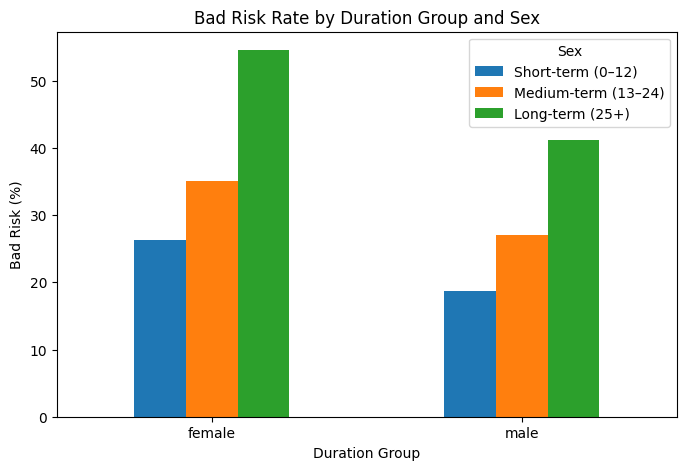

In [73]:
bad_risk = sex_duration_risk_percent['bad'].unstack()

bad_risk.plot(kind='bar', figsize=(8,5))

plt.title("Bad Risk Rate by Duration Group and Sex")
plt.xlabel("Duration Group")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.show()

Housing Analysis by Sex

In [74]:
df['Housing'].value_counts()

,count
Housing,
own,713
rent,179
free,108


In [75]:
pd.crosstab(df['Sex'], df['Housing'])

Housing,free,own,rent
Sex,,,
female,19,196,95
male,89,517,84


In [76]:
housing_sex_percent = pd.crosstab(df['Sex'], df['Housing'], normalize='index') * 100
print(housing_sex_percent)

Housing       free        own       rent
Sex                                     
female    6.129032  63.225806  30.645161
male     12.898551  74.927536  12.173913


In [77]:
pd.crosstab(df['Housing'], df['Risk'])

Risk,bad,good
Housing,,
free,44,64
own,186,527
rent,70,109


In [78]:
housing_risk_percent = pd.crosstab(df['Housing'], df['Risk'], normalize='index') * 100
print(housing_risk_percent)

Risk           bad       good
Housing                      
free     40.740741  59.259259
own      26.086957  73.913043
rent     39.106145  60.893855


In [79]:
housing_sex_risk = pd.crosstab(
    [df['Housing'], df['Sex']],
    df['Risk']
)

print(housing_sex_risk)

Risk            bad  good
Housing Sex              
free    female   11     8
        male     33    56
own     female   59   137
        male    127   390
rent    female   39    56
        male     31    53


In [80]:
housing_sex_risk_percent = pd.crosstab(
    [df['Housing'], df['Sex']],
    df['Risk'],
    normalize='index'
) * 100

print(housing_sex_risk_percent)

Risk                  bad       good
Housing Sex                         
free    female  57.894737  42.105263
        male    37.078652  62.921348
own     female  30.102041  69.897959
        male    24.564797  75.435203
rent    female  41.052632  58.947368
        male    36.904762  63.095238


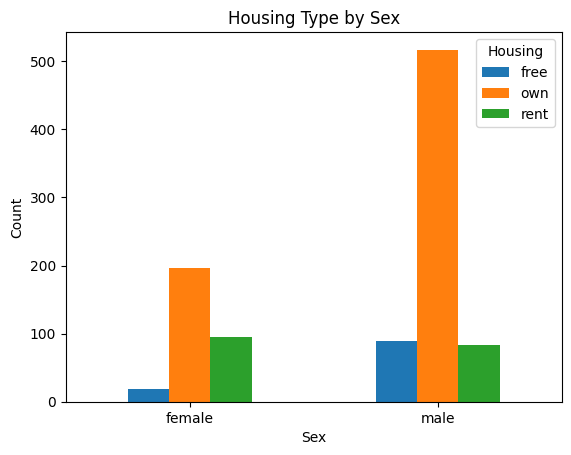

In [81]:
pd.crosstab(df['Sex'], df['Housing']).plot(kind='bar')

plt.title("Housing Type by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Housing")

plt.show()

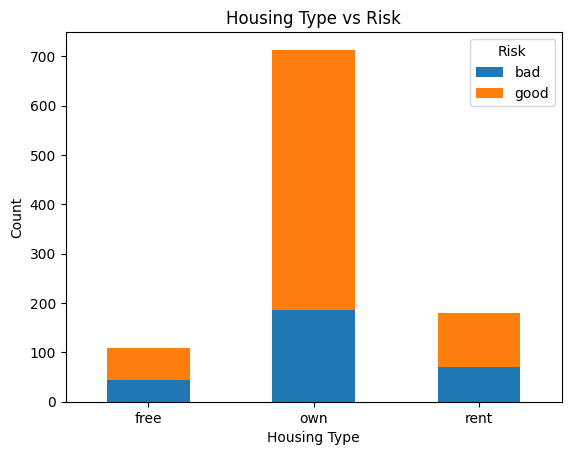

In [82]:
pd.crosstab(df['Housing'], df['Risk']).plot(kind='bar', stacked=True)

plt.title("Housing Type vs Risk")
plt.xlabel("Housing Type")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Risk")

plt.show()

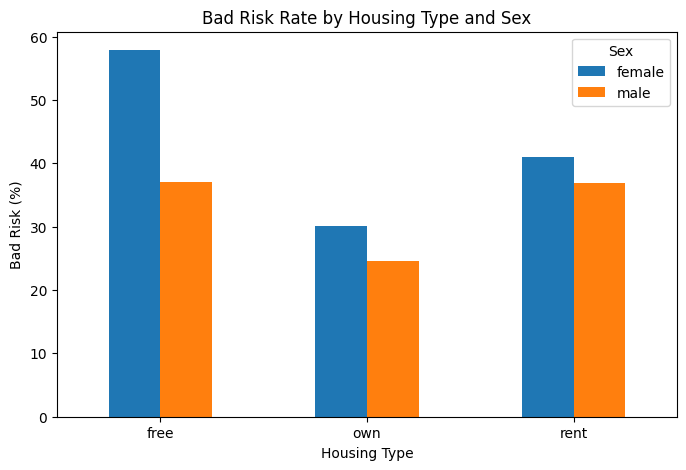

In [83]:
housing_bad = housing_sex_risk_percent['bad'].unstack()

housing_bad.plot(kind='bar', figsize=(8,5))

plt.title("Bad Risk Rate by Housing Type and Sex")
plt.xlabel("Housing Type")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.show()

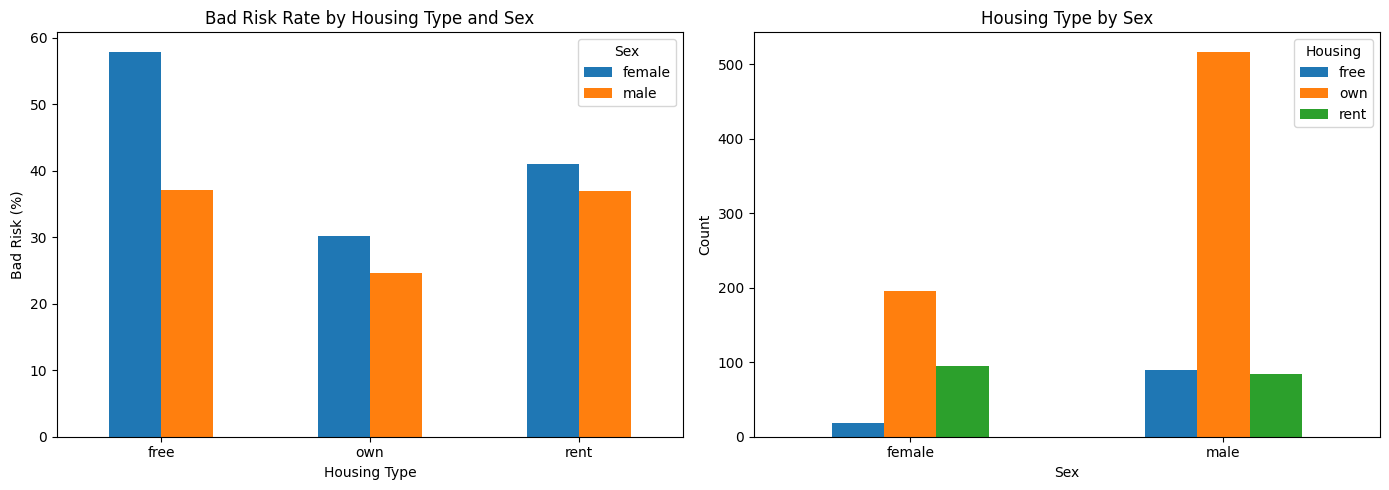

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Bad Risk Rate ---
housing_bad = housing_sex_risk_percent['bad'].unstack()

housing_bad.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Bad Risk Rate by Housing Type and Sex")
axes[0].set_xlabel("Housing Type")
axes[0].set_ylabel("Bad Risk (%)")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title="Sex")


# --- Plot 2: Housing Type by Sex ---
pd.crosstab(df['Sex'], df['Housing']).plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Housing Type by Sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title="Housing")


plt.tight_layout()
plt.show()

Saving Accounts Analysis by Sex

In [85]:
df['Saving accounts'].value_counts()

,count
Saving accounts,
little,603
unknown,183
moderate,103
quite rich,63
rich,48


In [86]:
pd.crosstab(df['Sex'], df['Saving accounts'])

Saving accounts,little,moderate,quite rich,rich,unknown
Sex,,,,,
female,194,32,16,19,49
male,409,71,47,29,134


In [87]:
saving_sex_percent = pd.crosstab(
    df['Sex'],
    df['Saving accounts'],
    normalize='index'
) * 100

print(saving_sex_percent)

Saving accounts     little   moderate  quite rich      rich    unknown
Sex                                                                   
female           62.580645  10.322581    5.161290  6.129032  15.806452
male             59.275362  10.289855    6.811594  4.202899  19.420290


In [88]:
pd.crosstab(df['Saving accounts'], df['Risk'])

Risk,bad,good
Saving accounts,,
little,217,386
moderate,34,69
quite rich,11,52
rich,6,42
unknown,32,151


In [89]:
saving_risk_percent = pd.crosstab(
    df['Saving accounts'],
    df['Risk'],
    normalize='index'
) * 100

print(saving_risk_percent)

Risk                   bad       good
Saving accounts                      
little           35.986733  64.013267
moderate         33.009709  66.990291
quite rich       17.460317  82.539683
rich             12.500000  87.500000
unknown          17.486339  82.513661


In [90]:
bad_saving = saving_risk_percent['bad']
print(bad_saving)

Saving accounts
little        35.986733
moderate      33.009709
quite rich    17.460317
rich          12.500000
unknown       17.486339
Name: bad, dtype: float64


In [91]:
pd.crosstab(
    [df['Saving accounts'], df['Sex']],
    df['Risk']
)

Risk                    bad  good
Saving accounts Sex              
little          female   76   118
                male    141   268
moderate        female   15    17
                male     19    52
quite rich      female    4    12
                male      7    40
rich            female    1    18
                male      5    24
unknown         female   13    36
                male     19   115

In [92]:
saving_sex_risk_percent = pd.crosstab(
    [df['Saving accounts'], df['Sex']],
    df['Risk'],
    normalize='index'
) * 100

print(saving_sex_risk_percent)

Risk                          bad       good
Saving accounts Sex                         
little          female  39.175258  60.824742
                male    34.474328  65.525672
moderate        female  46.875000  53.125000
                male    26.760563  73.239437
quite rich      female  25.000000  75.000000
                male    14.893617  85.106383
rich            female   5.263158  94.736842
                male    17.241379  82.758621
unknown         female  26.530612  73.469388
                male    14.179104  85.820896


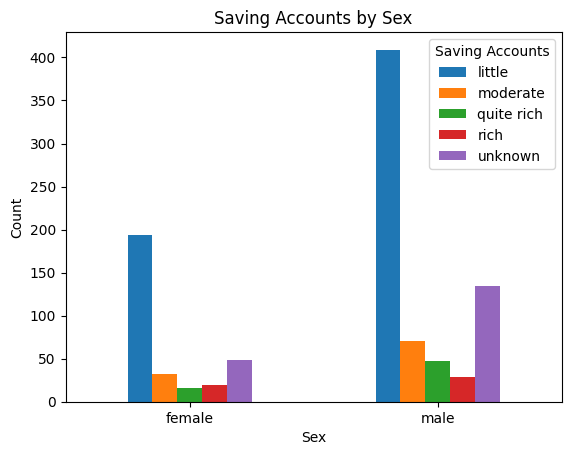

In [93]:
pd.crosstab(df['Sex'], df['Saving accounts']).plot(kind='bar')

plt.title("Saving Accounts by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Saving Accounts")

plt.show()

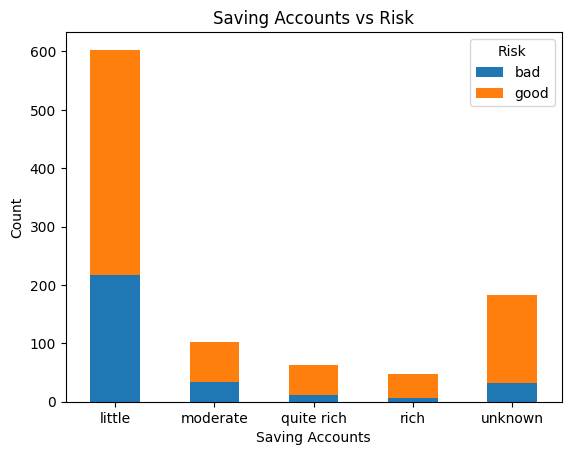

In [94]:
pd.crosstab(df['Saving accounts'], df['Risk']).plot(kind='bar', stacked=True)

plt.title("Saving Accounts vs Risk")
plt.xlabel("Saving Accounts")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Risk")

plt.show()

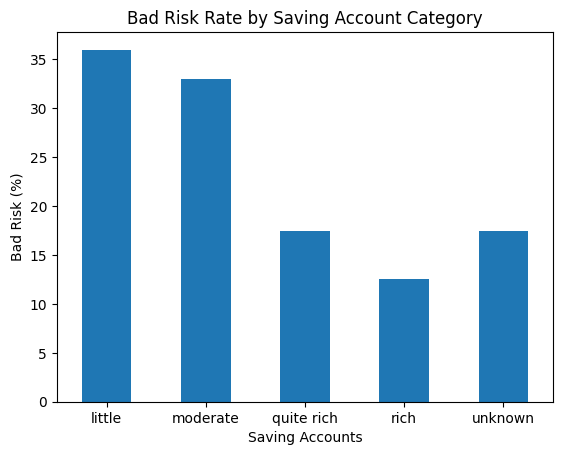

In [95]:
bad_saving.plot(kind='bar')

plt.title("Bad Risk Rate by Saving Account Category")
plt.xlabel("Saving Accounts")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)

plt.show()

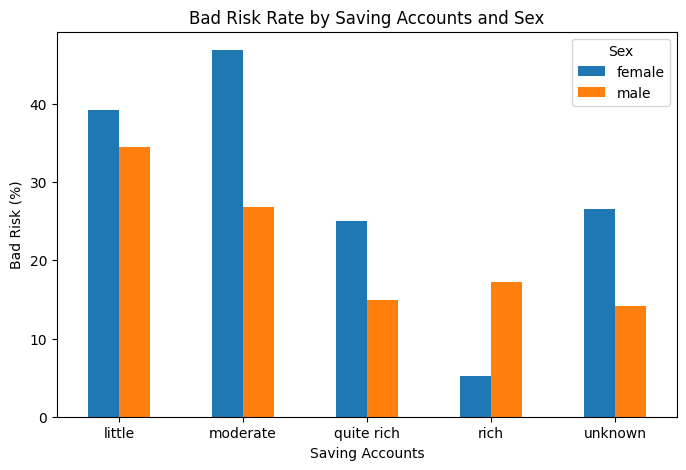

In [96]:
saving_sex_risk_percent['bad'].unstack().plot(kind='bar', figsize=(8,5))

plt.title("Bad Risk Rate by Saving Accounts and Sex")
plt.xlabel("Saving Accounts")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.show()

Checking Account Analysis by Sex

In [97]:
df['Checking account'].value_counts()

,count
Checking account,
unknown,394
little,274
moderate,269
rich,63


In [98]:
pd.crosstab(df['Sex'], df['Checking account'])

Checking account,little,moderate,rich,unknown
Sex,,,,
female,88,86,20,116
male,186,183,43,278


In [99]:
checking_sex_percent = pd.crosstab(
    df['Sex'],
    df['Checking account'],
    normalize='index'
) * 100

print(checking_sex_percent)

Checking account     little   moderate      rich    unknown
Sex                                                        
female            28.387097  27.741935  6.451613  37.419355
male              26.956522  26.521739  6.231884  40.289855


In [100]:
pd.crosstab(df['Checking account'], df['Risk'])

Risk,bad,good
Checking account,,
little,135,139
moderate,105,164
rich,14,49
unknown,46,348


In [101]:
checking_risk_percent = pd.crosstab(
    df['Checking account'],
    df['Risk'],
    normalize='index'
) * 100

print(checking_risk_percent)

Risk                    bad       good
Checking account                      
little            49.270073  50.729927
moderate          39.033457  60.966543
rich              22.222222  77.777778
unknown           11.675127  88.324873


In [102]:
bad_checking = checking_risk_percent['bad']
print(bad_checking)

Checking account
little      49.270073
moderate    39.033457
rich        22.222222
unknown     11.675127
Name: bad, dtype: float64


In [103]:
pd.crosstab(
    [df['Checking account'], df['Sex']],
    df['Risk']
)

Risk                     bad  good
Checking account Sex              
little           female   46    42
                 male     89    97
moderate         female   41    45
                 male     64   119
rich             female    4    16
                 male     10    33
unknown          female   18    98
                 male     28   250

In [104]:
checking_sex_risk_percent = pd.crosstab(
    [df['Checking account'], df['Sex']],
    df['Risk'],
    normalize='index'
) * 100

print(checking_sex_risk_percent)

Risk                           bad       good
Checking account Sex                         
little           female  52.272727  47.727273
                 male    47.849462  52.150538
moderate         female  47.674419  52.325581
                 male    34.972678  65.027322
rich             female  20.000000  80.000000
                 male    23.255814  76.744186
unknown          female  15.517241  84.482759
                 male    10.071942  89.928058


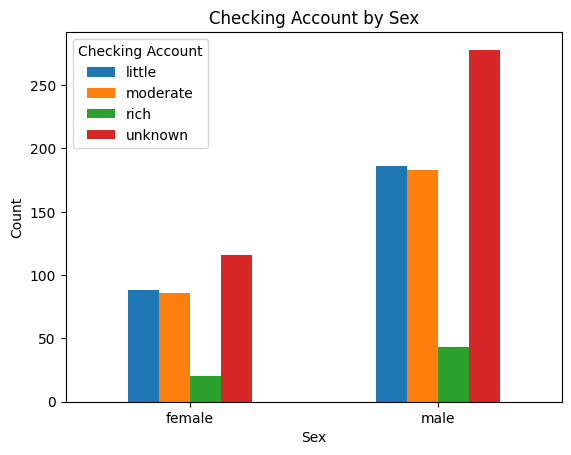

In [105]:
pd.crosstab(df['Sex'], df['Checking account']).plot(kind='bar')

plt.title("Checking Account by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Checking Account")

plt.show()

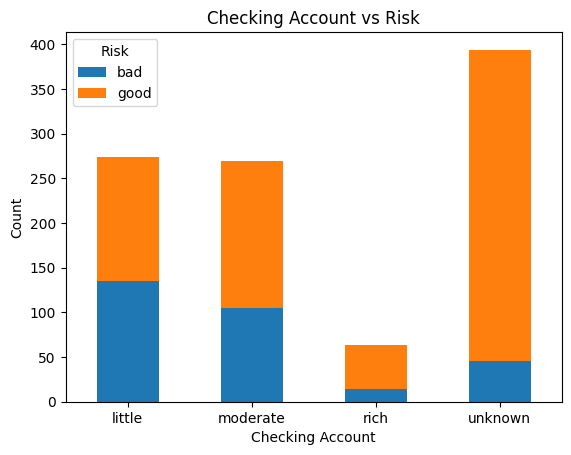

In [106]:
pd.crosstab(df['Checking account'], df['Risk']).plot(kind='bar', stacked=True)

plt.title("Checking Account vs Risk")
plt.xlabel("Checking Account")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Risk")

plt.show()

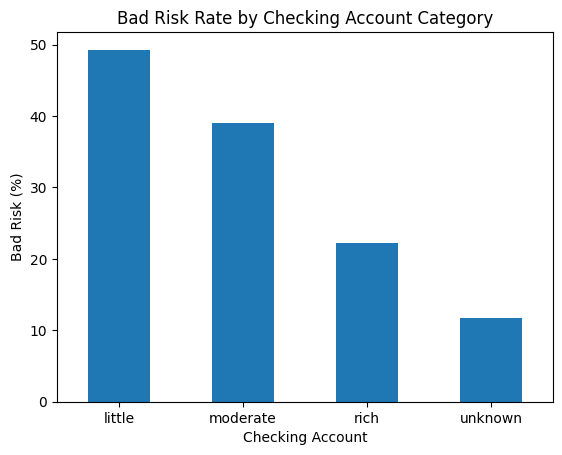

In [107]:
bad_checking.plot(kind='bar')

plt.title("Bad Risk Rate by Checking Account Category")
plt.xlabel("Checking Account")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)

plt.show()

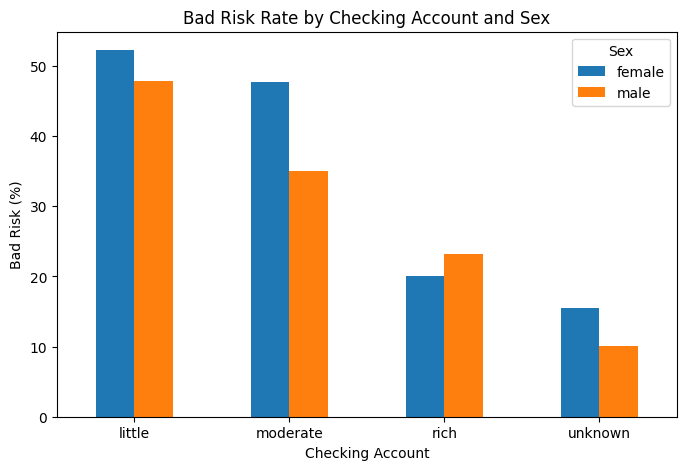

In [108]:
checking_sex_risk_percent['bad'].unstack().plot(kind='bar', figsize=(8,5))

plt.title("Bad Risk Rate by Checking Account and Sex")
plt.xlabel("Checking Account")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.show()

Job Analysis by Sex

In [109]:
df['Job'].value_counts().sort_index()

,count
Job,
0,22
1,200
2,630
3,148


In [110]:
pd.crosstab(df['Sex'], df['Job'])

Job,0,1,2,3
Sex,,,,
female,12,64,197,37
male,10,136,433,111


In [111]:
pd.crosstab(
    df['Sex'],
    df['Job'],
    normalize='index'
    )*100

Job,0,1,2,3
Sex,,,,
female,3.870968,20.645161,63.548387,11.935484
male,1.449275,19.710145,62.753623,16.086957


In [112]:
pd.crosstab(df['Job'], df['Risk'])

Risk,bad,good
Job,,
0,7,15
1,56,144
2,186,444
3,51,97


In [113]:
job_risk_percent = pd.crosstab(
    df['Job'],
    df['Risk'],
    normalize='index'
) * 100

print(job_risk_percent)

Risk        bad       good
Job                       
0     31.818182  68.181818
1     28.000000  72.000000
2     29.523810  70.476190
3     34.459459  65.540541


In [114]:
pd.crosstab(
    [df['Job'], df['Sex']],
    df['Risk']
)

Risk        bad  good
Job Sex              
0   female    5     7
    male      2     8
1   female   22    42
    male     34   102
2   female   66   131
    male    120   313
3   female   16    21
    male     35    76

In [115]:
job_sex_risk_percent = pd.crosstab(
    [df['Job'], df['Sex']],
    df['Risk'],
    normalize='index'
) * 100

print(job_sex_risk_percent)

Risk              bad       good
Job Sex                         
0   female  41.666667  58.333333
    male    20.000000  80.000000
1   female  34.375000  65.625000
    male    25.000000  75.000000
2   female  33.502538  66.497462
    male    27.713626  72.286374
3   female  43.243243  56.756757
    male    31.531532  68.468468


In [116]:
bad_job = job_risk_percent['bad']
print(bad_job)

Job
0    31.818182
1    28.000000
2    29.523810
3    34.459459
Name: bad, dtype: float64


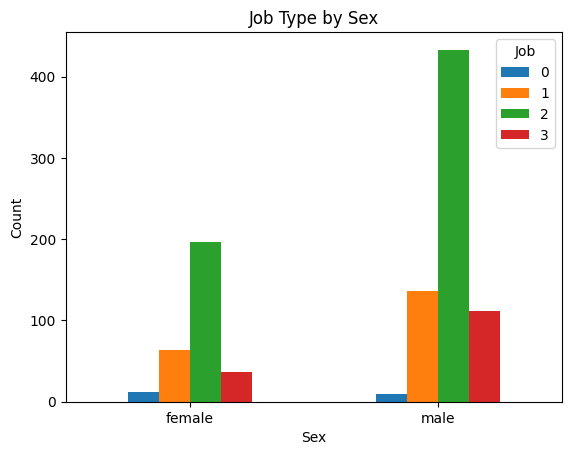

In [117]:
pd.crosstab(df['Sex'], df['Job']).plot(kind='bar')

plt.title("Job Type by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Job")

plt.show()

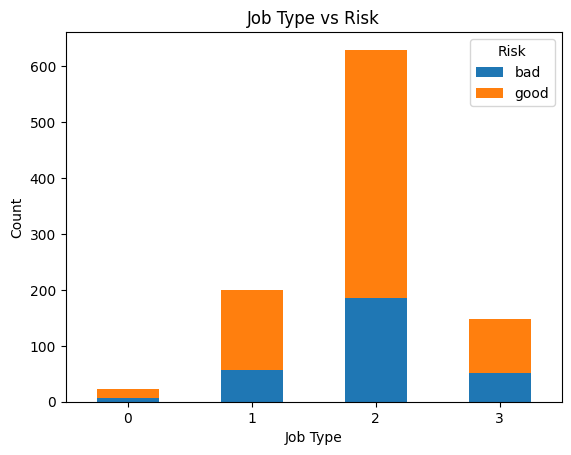

In [118]:
pd.crosstab(df['Job'], df['Risk']).plot(kind='bar', stacked=True)

plt.title("Job Type vs Risk")
plt.xlabel("Job Type")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Risk")

plt.show()

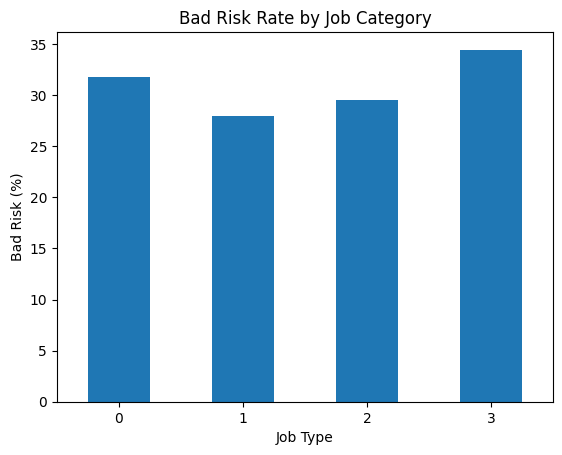

In [119]:
bad_job.plot(kind='bar')

plt.title("Bad Risk Rate by Job Category")
plt.xlabel("Job Type")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)

plt.show()

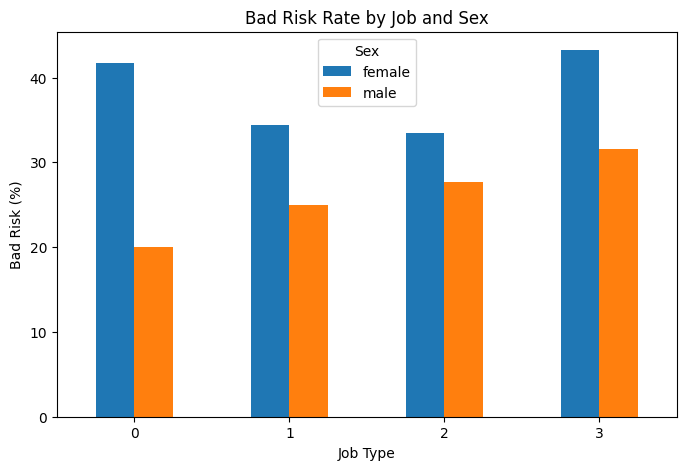

In [120]:
job_sex_risk_percent['bad'].unstack().plot(kind='bar', figsize=(8,5))

plt.title("Bad Risk Rate by Job and Sex")
plt.xlabel("Job Type")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.show()

Purpose Analysis by Sex

In [121]:
df['Purpose'].value_counts()

,count
Purpose,
car,337
radio/TV,280
furniture/equipment,181
business,97
education,59
repairs,22
domestic appliances,12
vacation/others,12


In [122]:
pd.crosstab(df['Sex'], df['Purpose'])

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Sex,,,,,,,,
female,19,94,6,24,74,85,5,3
male,78,243,6,35,107,195,17,9


In [123]:
purpose_sex_percent = pd.crosstab(
    df['Sex'],
    df['Purpose'],
    normalize='index'
) * 100

print(purpose_sex_percent)

Purpose   business        car  domestic appliances  education  \
Sex                                                             
female    6.129032  30.322581             1.935484   7.741935   
male     11.304348  35.217391             0.869565   5.072464   

Purpose  furniture/equipment   radio/TV   repairs  vacation/others  
Sex                                                                 
female             23.870968  27.419355  1.612903         0.967742  
male               15.507246  28.260870  2.463768         1.304348  


In [124]:
pd.crosstab(df['Purpose'], df['Risk'])

Risk,bad,good
Purpose,,
business,34,63
car,106,231
domestic appliances,4,8
education,23,36
furniture/equipment,58,123
radio/TV,62,218
repairs,8,14
vacation/others,5,7


In [125]:
purpose_risk_percent = pd.crosstab(
    df['Purpose'],
    df['Risk'],
    normalize='index'
) * 100

print(purpose_risk_percent)

Risk                       bad       good
Purpose                                  
business             35.051546  64.948454
car                  31.454006  68.545994
domestic appliances  33.333333  66.666667
education            38.983051  61.016949
furniture/equipment  32.044199  67.955801
radio/TV             22.142857  77.857143
repairs              36.363636  63.636364
vacation/others      41.666667  58.333333


In [126]:
pd.crosstab(
    [df['Purpose'], df['Sex']],
    df['Risk']
)

Risk                        bad  good
Purpose             Sex              
business            female    7    12
                    male     27    51
car                 female   40    54
                    male     66   177
domestic appliances female    2     4
                    male      2     4
education           female    9    15
                    male     14    21
furniture/equipment female   28    46
                    male     30    77
radio/TV            female   19    66
                    male     43   152
repairs             female    2     3
                    male      6    11
vacation/others     female    2     1
                    male      3     6

In [127]:
purpose_sex_risk_percent = pd.crosstab(
    [df['Purpose'], df['Sex']],
    df['Risk'],
    normalize='index'
) * 100

print(purpose_sex_risk_percent)

Risk                              bad       good
Purpose             Sex                         
business            female  36.842105  63.157895
                    male    34.615385  65.384615
car                 female  42.553191  57.446809
                    male    27.160494  72.839506
domestic appliances female  33.333333  66.666667
                    male    33.333333  66.666667
education           female  37.500000  62.500000
                    male    40.000000  60.000000
furniture/equipment female  37.837838  62.162162
                    male    28.037383  71.962617
radio/TV            female  22.352941  77.647059
                    male    22.051282  77.948718
repairs             female  40.000000  60.000000
                    male    35.294118  64.705882
vacation/others     female  66.666667  33.333333
                    male    33.333333  66.666667


In [128]:
bad_purpose = purpose_risk_percent['bad']

print(bad_purpose)

Purpose
business               35.051546
car                    31.454006
domestic appliances    33.333333
education              38.983051
furniture/equipment    32.044199
radio/TV               22.142857
repairs                36.363636
vacation/others        41.666667
Name: bad, dtype: float64


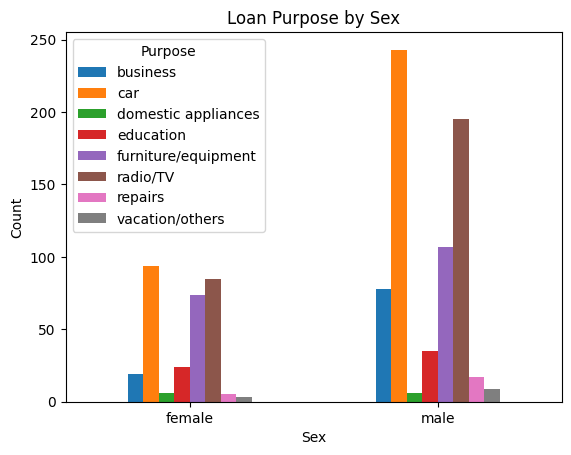

In [129]:
pd.crosstab(df['Sex'], df['Purpose']).plot(kind='bar')

plt.title("Loan Purpose by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Purpose")

plt.show()

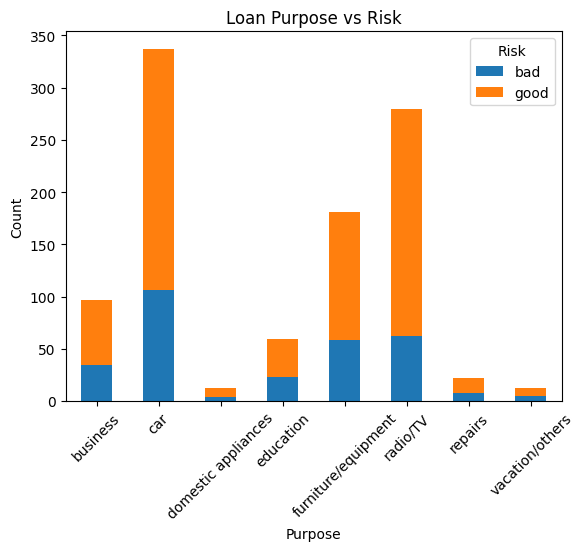

In [130]:
pd.crosstab(df['Purpose'], df['Risk']).plot(kind='bar', stacked=True)

plt.title("Loan Purpose vs Risk")
plt.xlabel("Purpose")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.legend(title="Risk")

plt.show()

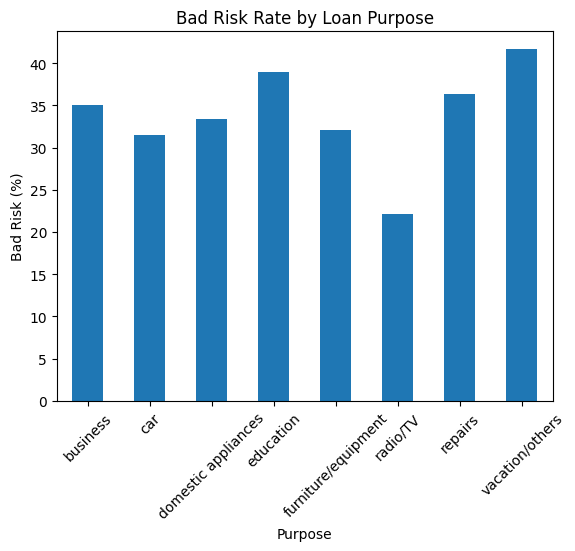

In [131]:
bad_purpose.plot(kind='bar')

plt.title("Bad Risk Rate by Loan Purpose")
plt.xlabel("Purpose")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=45)

plt.show()

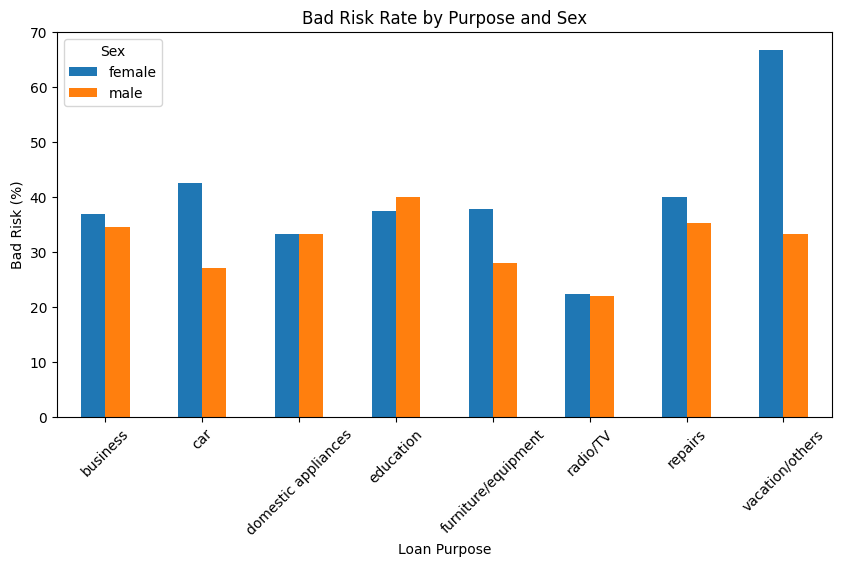

In [132]:
purpose_sex_risk_percent['bad'].unstack().plot(kind='bar', figsize=(10,5))

plt.title("Bad Risk Rate by Purpose and Sex")
plt.xlabel("Loan Purpose")
plt.ylabel("Bad Risk (%)")

plt.xticks(rotation=45)
plt.legend(title="Sex")

plt.show()

# Initial Bias Investigation

In [133]:
df['y'] = [1 if y == 'good'else 0 for y in df['Risk']]

prev = df['y'].mean()
prev_sex = df.groupby('Sex')['y'].mean()
diff = (prev_sex['male'] - prev_sex['female'])*100

print(f'Males: {prev_sex['male'] *100:.2f}%')
print(f'Females: {prev_sex['female'] *100:.2f}%')
print()
print('Interpretation:')
print(f'Males are {diff:.2f}% more likely to receive a loan than females')
print('This suggests potential gender bias worth investigating.')


Males: 72.32%
Females: 64.84%

Interpretation:
Males are 7.48% more likely to receive a loan than females
This suggests potential gender bias worth investigating.


The dataset itself has unequal distributions between groups -> worth investigating for fairness.

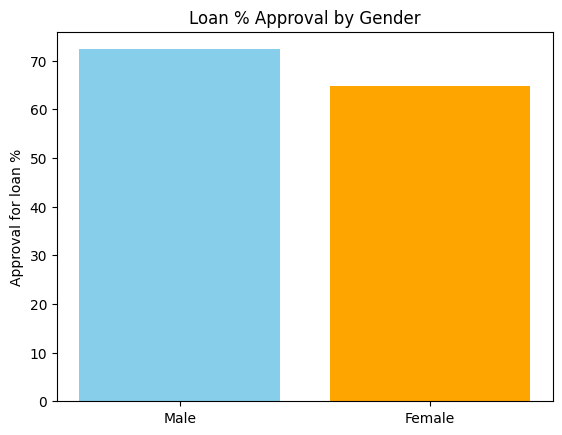

In [134]:

plt.bar(
    ['Male', 'Female'],
    [prev_sex['male']*100, prev_sex['female']*100],
    color=['skyblue', 'orange']
)

plt.ylabel('Approval for loan %')
plt.title('Loan % Approval by Gender')

plt.show()

# Data Preparation

In [135]:
# Reload original data to undo EDA modifications
df = pd.read_csv(url, sep=',')
df['y'] = (df['Risk'] == 'good').astype(int)
feature_names = [
    'Age',
    'Sex',
    'Job',              # 0=Unskilled+NonResident, 1=Unskilled+Resident, 2=Skilled, 3=Highly Skilled
    'Housing',          # rent, free, own
    'Saving accounts',  # savings category
    'Checking account', # checking account category
    'Credit amount',    # loan size
    'Duration',         # loan duration (months)
    'Purpose'           # reason for loan
]
target_name = 'Risk'


def data_processing(data, features, target_name):
    df = data.copy()

    # Remove unskilled non-residents (Job=0)
    # Check gender distribution in removed group first
    removed = df[df['Job'] == 0]
    print(f'Removing {len(removed)} rows with Job=0 (unskilled non-resident)')
    print(f'Gender distribution in removed group: {removed["Sex"].value_counts().to_dict()}')
    df = df[df['Job'] != 0]

    # Encode sex as numeric (keep for group tracking)
    df['Sex'] = df['Sex'].map({'male': 1, 'female': 2})
    sex = df['Sex'].values

    # Target variable
    df['target'] = (df[target_name] == 'good').astype(int)
    target = df['target'].values

    # Keep original for bias analysis
    df = df[features + ['target', target_name]]
    df_processed = df[features].copy()

    # One-hot encode categorical features
    cols_without_nulls = ['Job', 'Housing', 'Purpose', 'Sex']
    cols_with_nulls    = ['Saving accounts', 'Checking account']

    df_processed = pd.get_dummies(
        df_processed, columns=cols_without_nulls,
        prefix_sep='_', dummy_na=False, drop_first=True
    )
    df_processed = pd.get_dummies(
        df_processed, columns=cols_with_nulls,
        prefix_sep='_', dummy_na=True, drop_first=True
    )

    return df_processed, df, target, sex


data, data_original, target, group = data_processing(df, feature_names, target_name)

print(f'\nFinal dataset shape: {data.shape}')
print(f'Features: {data.columns.tolist()}')

Removing 22 rows with Job=0 (unskilled non-resident)
Gender distribution in removed group: {'female': 12, 'male': 10}

Final dataset shape: (978, 22)
Features: ['Age', 'Credit amount', 'Duration', 'Job_2', 'Job_3', 'Housing_own', 'Housing_rent', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'Sex_2', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Saving accounts_nan', 'Checking account_moderate', 'Checking account_rich', 'Checking account_nan']


In [136]:
data_original

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target,Risk
0,67,1,2,own,NaN,little,1169,6,radio/TV,1,good
1,22,2,2,own,little,moderate,5951,48,radio/TV,0,bad
2,49,1,1,own,little,NaN,2096,12,education,1,good
3,45,1,2,free,little,little,7882,42,furniture/equipment,1,good
4,53,1,2,free,little,little,4870,24,car,0,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,31,2,1,own,little,NaN,1736,12,furniture/equipment,1,good
996,40,1,3,own,little,little,3857,30,car,1,good
997,38,1,2,own,little,NaN,804,12,radio/TV,1,good
998,23,1,2,free,little,little,1845,45,radio/TV,0,bad


In [137]:
data.columns

Index(['Age', 'Credit amount', 'Duration', 'Job_2', 'Job_3', 'Housing_own',
       'Housing_rent', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Sex_2',
       'Saving accounts_moderate', 'Saving accounts_quite rich',
       'Saving accounts_rich', 'Saving accounts_nan',
       'Checking account_moderate', 'Checking account_rich',
       'Checking account_nan'],
      dtype='object')

In [138]:
#combined stratification key
# Encodes all 4 combinations: male/good, male/bad, female/good, female/bad
stratify_key = target * 10 + (group == 2).astype(int)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    data, target, group,
    test_size=0.2,
    random_state=0,
    stratify=stratify_key
)

group_train = np.array(group_train)
group_test  = np.array(group_test)
y_train     = np.array(y_train)
y_test      = np.array(y_test)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'Male test:   {(group_test==1).sum()}')
print(f'Female test: {(group_test==2).sum()}')
print(f'Female good (y=1): {((group_test==2) & (y_test==1)).sum()}')
print(f'Female bad  (y=0): {((group_test==2) & (y_test==0)).sum()}')
print(f'Male good   (y=1): {((group_test==1) & (y_test==1)).sum()}')
print(f'Male bad    (y=0): {((group_test==1) & (y_test==0)).sum()}')
print('\nNote: small female test set makes fairness metrics noisy.')

Train size: 782
Test size:  196
Male test:   136
Female test: 60
Female good (y=1): 39
Female bad  (y=0): 21
Male good   (y=1): 98
Male bad    (y=0): 38

Note: small female test set makes fairness metrics noisy.


In [139]:
# Positive outcome rate in training data
male_rate = y_train[group_train == 1].mean()
female_rate = y_train[group_train == 2].mean()

diff = (male_rate - female_rate) * 100

print("train data:")
print(f"Male approval rate:   {male_rate * 100:.2f}%")
print(f"Female approval rate: {female_rate * 100:.2f}%")

print()
print("Interpretation:")
print(f"Males are {diff:.2f}% more likely to receive a loan than females.")
print("This suggests potential gender bias worth investigating.")

train data:
Male approval rate:   72.24%
Female approval rate: 65.13%

Interpretation:
Males are 7.12% more likely to receive a loan than females.
This suggests potential gender bias worth investigating.


## Fairness Definition: Statistical Parity

We use **Statistical Parity Difference (SPD = 0)** as our primary fairness criterion.



In [140]:
def compute_fairness_metrics(y_pred, y_true, groups):
    """
    SPD      = Statistical Parity Difference  (ideal: 0)
    DI       = Disparate Impact               (ideal: 1)
    TPR_diff = True Positive Rate difference  (ideal: 0) -- equalized odds
    FPR_diff = False Positive Rate difference (ideal: 0) -- equalized odds

    Female (group==2) = unprivileged
    Male   (group==1) = privileged
    """
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    groups = np.array(groups)

    male_mask   = groups == 1
    female_mask = groups == 2

    priv_rate   = np.mean(y_pred[male_mask])
    unpriv_rate = np.mean(y_pred[female_mask])

    spd = unpriv_rate - priv_rate
    di  = unpriv_rate / priv_rate if priv_rate != 0 else np.nan

    tpr_m = np.mean(y_pred[male_mask   & (y_true==1)]) if (male_mask   & (y_true==1)).sum()>0 else np.nan
    tpr_f = np.mean(y_pred[female_mask & (y_true==1)]) if (female_mask & (y_true==1)).sum()>0 else np.nan
    fpr_m = np.mean(y_pred[male_mask   & (y_true==0)]) if (male_mask   & (y_true==0)).sum()>0 else np.nan
    fpr_f = np.mean(y_pred[female_mask & (y_true==0)]) if (female_mask & (y_true==0)).sum()>0 else np.nan

    return {
        'SPD':      round(float(spd),           4),
        'DI':       round(float(di),            4),
        'TPR_diff': round(float(tpr_f - tpr_m), 4),
        'FPR_diff': round(float(fpr_f - fpr_m), 4)
    }

print('Fairness metrics defined. Ideal: SPD=0, DI=1, TPR_diff=0, FPR_diff=0')

Fairness metrics defined. Ideal: SPD=0, DI=1, TPR_diff=0, FPR_diff=0


# Initial training

##  Baseline Models — WITH Sex_2


In [141]:
# Scale for logistic regression
X_train_lr = X_train.copy()
X_test_lr  = X_test.copy()
num_cols   = ['Age', 'Credit amount', 'Duration']
scaler     = StandardScaler()
X_train_lr[num_cols] = scaler.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols]  = scaler.transform(X_test_lr[num_cols])

lr_with_sex = LogisticRegression(max_iter=1000)
lr_with_sex.fit(X_train_lr, y_train)
lr_with_sex_preds = lr_with_sex.predict(X_test_lr)

rf_with_sex = RandomForestClassifier(n_estimators=100, random_state=0)
rf_with_sex.fit(X_train, y_train)
rf_with_sex_preds = rf_with_sex.predict(X_test)

lr_with_sex_acc     = balanced_accuracy_score(y_test, lr_with_sex_preds)
rf_with_sex_acc     = balanced_accuracy_score(y_test, rf_with_sex_preds)
lr_with_sex_metrics = compute_fairness_metrics(lr_with_sex_preds, y_test, group_test)
rf_with_sex_metrics = compute_fairness_metrics(rf_with_sex_preds, y_test, group_test)

print('=== Baseline WITH Sex_2 ===')
print(f'LR Balanced Accuracy: {lr_with_sex_acc:.4f}')
print(f'RF Balanced Accuracy: {rf_with_sex_acc:.4f}')
print(f'LR Fairness: {lr_with_sex_metrics}')
print(f'RF Fairness: {rf_with_sex_metrics}')

=== Baseline WITH Sex_2 ===
LR Balanced Accuracy: 0.5687
RF Balanced Accuracy: 0.6305
LR Fairness: {'SPD': -0.0363, 'DI': 0.9575, 'TPR_diff': -0.016, 'FPR_diff': -0.0489}
RF Fairness: {'SPD': -0.0142, 'DI': 0.9829, 'TPR_diff': 0.0251, 'FPR_diff': -0.0388}


 ## Baseline Models — WITHOUT Sex_2

In [142]:
X_train_ns    = X_train.drop(columns=['Sex_2'])
X_test_ns     = X_test.drop(columns=['Sex_2'])
X_train_lr_ns = X_train_lr.drop(columns=['Sex_2'])
X_test_lr_ns  = X_test_lr.drop(columns=['Sex_2'])

print(f'Features with Sex_2:    {X_train_lr.shape[1]}')
print(f'Features without Sex_2: {X_train_lr_ns.shape[1]}')
print(f'Remaining features: {X_train_lr_ns.columns.tolist()}')

lr_base = LogisticRegression(max_iter=1000)
lr_base.fit(X_train_lr_ns, y_train)
lr_base_preds = lr_base.predict(X_test_lr_ns)

rf_base = RandomForestClassifier(n_estimators=100, random_state=0)
rf_base.fit(X_train_ns, y_train)
rf_base_preds = rf_base.predict(X_test_ns)

lr_base_acc     = balanced_accuracy_score(y_test, lr_base_preds)
rf_base_acc     = balanced_accuracy_score(y_test, rf_base_preds)
lr_base_metrics = compute_fairness_metrics(lr_base_preds, y_test, group_test)
rf_base_metrics = compute_fairness_metrics(rf_base_preds, y_test, group_test)

print('=== Baseline WITHOUT Sex_2 ===')
print(f'LR Balanced Accuracy: {lr_base_acc:.4f}')
print(f'RF Balanced Accuracy: {rf_base_acc:.4f}')
print(f'LR Fairness: {lr_base_metrics}')
print(f'RF Fairness: {rf_base_metrics}')
print('\nKey finding: if SPD != 0, bias persists through proxy features.')

Features with Sex_2:    22
Features without Sex_2: 21
Remaining features: ['Age', 'Credit amount', 'Duration', 'Job_2', 'Job_3', 'Housing_own', 'Housing_rent', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Saving accounts_nan', 'Checking account_moderate', 'Checking account_rich', 'Checking account_nan']
=== Baseline WITHOUT Sex_2 ===
LR Balanced Accuracy: 0.5554
RF Balanced Accuracy: 0.5966
LR Fairness: {'SPD': 0.0377, 'DI': 1.0446, 'TPR_diff': 0.0455, 'FPR_diff': 0.0464}
RF Fairness: {'SPD': 0.0284, 'DI': 1.0339, 'TPR_diff': 0.061, 'FPR_diff': 0.0038}

Key finding: if SPD != 0, bias persists through proxy features.


## Model Evaluation

In [143]:
comparison = pd.DataFrame({
    'Model':        ['LR with Sex', 'LR without Sex', 'RF with Sex', 'RF without Sex'],
    'Balanced Acc': [lr_with_sex_acc, lr_base_acc, rf_with_sex_acc, rf_base_acc],
    'SPD':          [lr_with_sex_metrics['SPD'], lr_base_metrics['SPD'],
                     rf_with_sex_metrics['SPD'], rf_base_metrics['SPD']],
    'TPR_diff':     [lr_with_sex_metrics['TPR_diff'], lr_base_metrics['TPR_diff'],
                     rf_with_sex_metrics['TPR_diff'], rf_base_metrics['TPR_diff']]
})
print('=== With Sex vs Without Sex ===')
print(comparison.to_string(index=False))

=== With Sex vs Without Sex ===
         Model  Balanced Acc     SPD  TPR_diff
   LR with Sex      0.568724 -0.0363   -0.0160
LR without Sex      0.555425  0.0377    0.0455
   RF with Sex      0.630521 -0.0142    0.0251
RF without Sex      0.596623  0.0284    0.0610


 Statistical Parity Difference:
  - LR: 5.59%
  - RF: -5.47%
 Disparate Impact:
  - LR: 106.65%
  - RF: 93.54%

  Interpertation:
  
  It seems the logistic regression model favors females more than males where as random forest does the opposite. However, these diffences are not extreme, but it still worth investigating how some preprocessing fairnessness techniques might achieve a better balance between them.

# Shap explainability

In [144]:

shap.initjs()

rng    = np.random.RandomState(0)
N_BG   = 200
N_SHAP = 300

X_tr_lr_f = X_train_lr_ns.astype(np.float64)
X_te_lr_f = X_test_lr_ns.astype(np.float64)
X_tr_rf_f = X_train_ns.astype(np.float64)
X_te_rf_f = X_test_ns.astype(np.float64)

bg_lr    = rng.choice(len(X_tr_lr_f), size=min(N_BG,   len(X_tr_lr_f)), replace=False)
si_lr    = rng.choice(len(X_te_lr_f), size=min(N_SHAP, len(X_te_lr_f)), replace=False)
bg_rf    = rng.choice(len(X_tr_rf_f), size=min(N_BG,   len(X_tr_rf_f)), replace=False)
si_rf    = rng.choice(len(X_te_rf_f), size=min(N_SHAP, len(X_te_rf_f)), replace=False)

X_bg_lr  = X_tr_lr_f.iloc[bg_lr]
X_sh_lr  = X_te_lr_f.iloc[si_lr]
X_bg_rf  = X_tr_rf_f.iloc[bg_rf]
X_sh_rf  = X_te_rf_f.iloc[si_rf]

g_sh_lr  = group_test[si_lr]
g_sh_rf  = group_test[si_rf]

print('SHAP setup complete.')

SHAP setup complete.


## Logistic regression explainability

=== Logistic Regression — Global SHAP ===


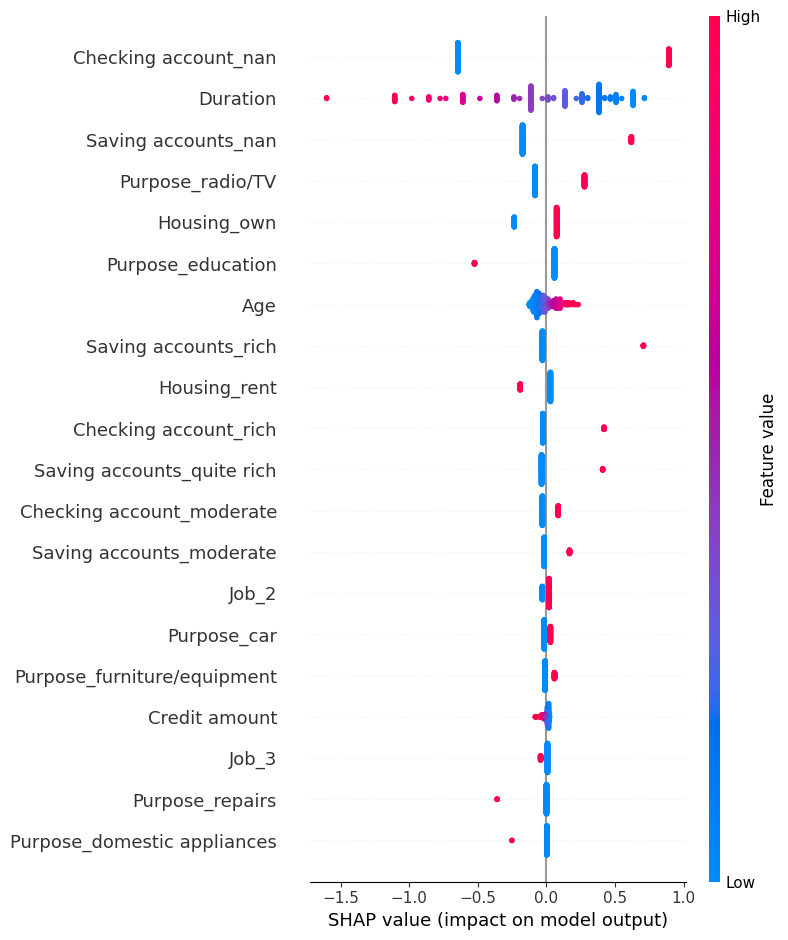

In [145]:
# LR SHAP
explainer_lr = shap.LinearExplainer(lr_base, X_bg_lr.values)
shap_lr      = explainer_lr.shap_values(X_sh_lr.values)
if isinstance(shap_lr, list):
    shap_lr = shap_lr[1]

print('=== Logistic Regression — Global SHAP ===')
shap.summary_plot(
    np.asarray(shap_lr, dtype=np.float64),
    X_sh_lr.values,
    feature_names=X_sh_lr.columns.tolist(),
    show=True)

plt.show()


## Random forest regression explainability

=== Random Forest — Global SHAP ===


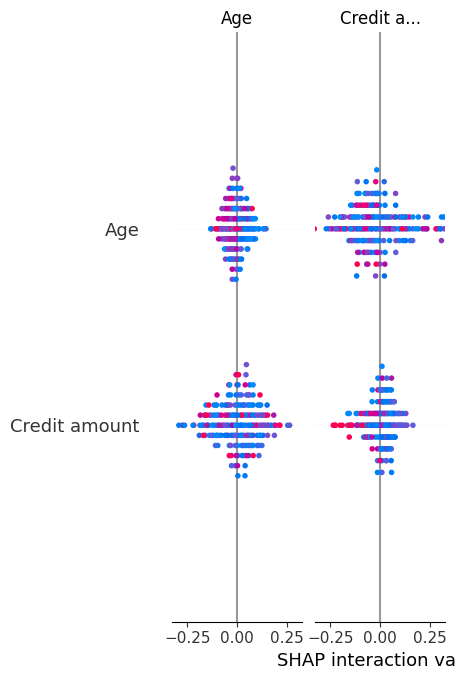

In [146]:
# RF SHAP
explainer_rf = shap.TreeExplainer(rf_base)
shap_rf      = explainer_rf.shap_values(X_sh_rf, approximate=True)
if isinstance(shap_rf, list):
    shap_rf = shap_rf[1]

print('=== Random Forest — Global SHAP ===')
shap.summary_plot(
    np.asarray(shap_rf, dtype=np.float64),
    X_sh_rf.values,
    feature_names=X_sh_rf.columns.tolist(),
    show=True)

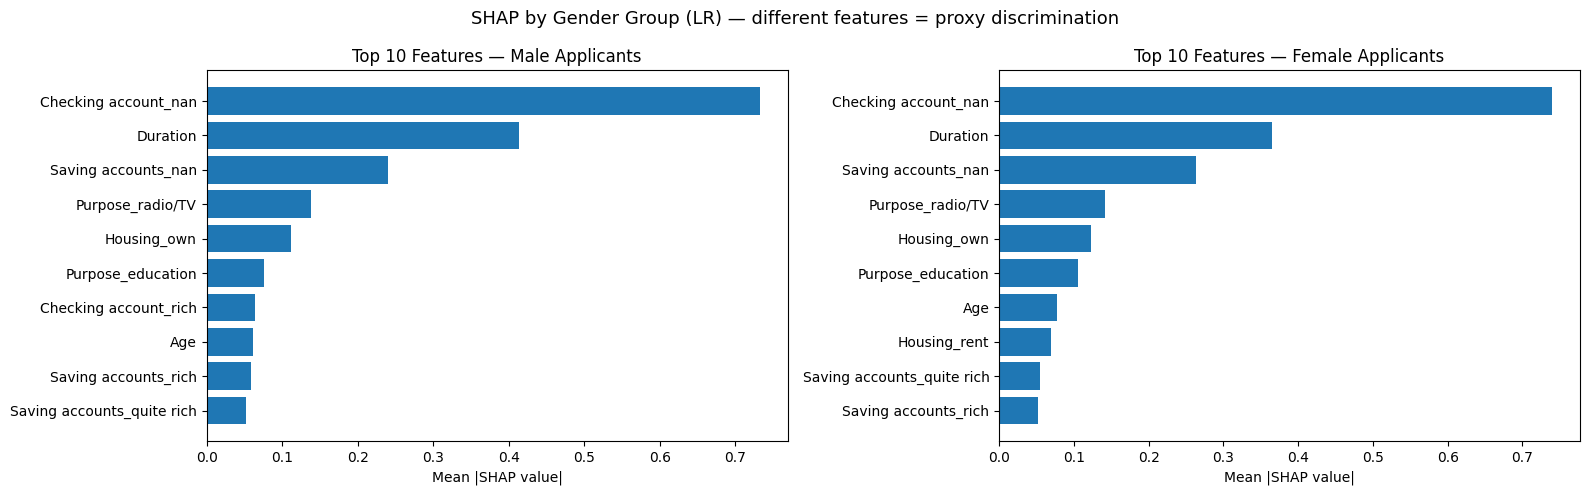

In [147]:
# SHAP by gender group
male_m   = g_sh_lr == 1
female_m = g_sh_lr == 2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, mask, title in zip(axes, [male_m, female_m], ['Male Applicants', 'Female Applicants']):
    mean_abs = np.abs(shap_lr[mask]).mean(axis=0)
    fnames   = X_sh_lr.columns.tolist()
    idx      = np.argsort(mean_abs)
    ax.barh([fnames[i] for i in idx[-10:]], mean_abs[idx[-10:]])
    ax.set_title(f'Top 10 Features — {title}', fontsize=12)
    ax.set_xlabel('Mean |SHAP value|')

plt.suptitle('SHAP by Gender Group (LR) — different features = proxy discrimination', fontsize=13)
plt.tight_layout()
plt.show()

## PREPROCESSING METHODS

## METHOD 1: REWEIGHING

In [148]:
def compute_reweighing_weights(y_train, group_train):
    """
    Reweighing targeting STATISTICAL PARITY.

    Weight formula: w = P(group) * P(label) / P(group AND label)
    """
    y_train     = np.array(y_train)
    group_train = np.array(group_train)
    weights     = np.ones(len(y_train))

    for g in np.unique(group_train):
        for l in np.unique(y_train):
            mask = (group_train == g) & (y_train == l)
            p_g  = np.mean(group_train == g)
            p_l  = np.mean(y_train == l)
            obs  = np.mean(mask)
            if obs > 0:
                weights[mask] = (p_g * p_l) / obs

    return weights


sample_weights = compute_reweighing_weights(y_train, group_train)

print('=== Reweighing Weights (Targeting Statistical Parity) ===')
for g in [1, 2]:
    for l in [0, 1]:
        mask = (group_train == g) & (y_train == l)
        if mask.sum() > 0:
            print(f'  {"male" if g==1 else "female"}/{"good" if l==1 else "bad"}: '
                  f'n={mask.sum()}, weight={sample_weights[mask].mean():.4f}')

=== Reweighing Weights (Targeting Statistical Parity) ===
  male/bad: n=151, weight=1.0780
  male/good: n=393, weight=0.9700
  female/bad: n=83, weight=0.8580
  female/good: n=155, weight=1.0760


In [149]:
lr_rw = LogisticRegression(max_iter=1000)
lr_rw.fit(X_train_lr_ns, y_train, sample_weight=sample_weights)
lr_rw_preds = lr_rw.predict(X_test_lr_ns)

rf_rw = RandomForestClassifier(n_estimators=100, random_state=0)
rf_rw.fit(X_train_ns, y_train, sample_weight=sample_weights)
rf_rw_preds = rf_rw.predict(X_test_ns)

lr_rw_acc     = balanced_accuracy_score(y_test, lr_rw_preds)
rf_rw_acc     = balanced_accuracy_score(y_test, rf_rw_preds)
lr_rw_metrics = compute_fairness_metrics(lr_rw_preds, y_test, group_test)
rf_rw_metrics = compute_fairness_metrics(rf_rw_preds, y_test, group_test)

print('=== Reweighing Results ===')
print(f'LR: acc={lr_rw_acc:.4f}, {lr_rw_metrics}')
print(f'RF: acc={rf_rw_acc:.4f}, {rf_rw_metrics}')

=== Reweighing Results ===
LR: acc=0.5639, {'SPD': 0.0451, 'DI': 1.0538, 'TPR_diff': 0.0455, 'FPR_diff': 0.0727}
RF: acc=0.6184, {'SPD': 0.0098, 'DI': 1.0119, 'TPR_diff': 0.0712, 'FPR_diff': -0.0652}


## METHOD 2: DECORRELATION

In [150]:
def decorrelate_features(X_train, X_test, sex_train, sex_test, lambda_param=0.0):
    """
    Decorrelation targeting STATISTICAL PARITY.
    lambda=0 -> fully decorrelated (max fairness)
    lambda=1 -> original features unchanged
    """
    X_tr = X_train.copy().astype(np.float64)
    X_te = X_test.copy().astype(np.float64)

    p      = sex_train.astype(np.float64)
    p_mean = p.mean()
    p_c    = p - p_mean

    for col in X_tr.columns:
        x_tr    = X_tr[col].values
        tr_mean = x_tr.mean()
        x_tr_c  = x_tr - tr_mean

        beta      = np.dot(x_tr_c, p_c) / np.dot(p_c, p_c)
        r_tr      = x_tr_c - beta * p_c
        X_tr[col] = r_tr + lambda_param * (x_tr_c - r_tr)

        x_te      = X_te[col].values
        x_te_c    = x_te - tr_mean
        p_te_c    = sex_test.astype(np.float64) - p_mean
        r_te      = x_te_c - beta * p_te_c
        X_te[col] = r_te + lambda_param * (x_te_c - r_te)

    return X_tr, X_te


sex_train_vals = (group_train == 2).astype(float)
sex_test_vals  = (group_test  == 2).astype(float)

# Verify it works
X_check, _ = decorrelate_features(
    X_train_lr_ns, X_test_lr_ns,
    sex_train_vals, sex_test_vals, 0.0)

print('=== Correlation with Sex: Before -> After ===')
for col in X_train_lr_ns.columns:
    before = np.corrcoef(X_train_lr_ns[col].values, sex_train_vals)[0,1]
    after  = np.corrcoef(X_check[col].values, sex_train_vals)[0,1]
    if abs(before) > 0.02:
        print(f'  {col:35s}: {before:+.4f} -> {after:+.4f}')

print(f'\nFeatures actually changed: {not np.allclose(X_train_lr_ns.values, X_check.values)}')

=== Correlation with Sex: Before -> After ===
  Age                                : -0.1725 -> +0.0000
  Credit amount                      : -0.0808 -> -0.0000
  Duration                           : -0.0798 -> -0.0000
  Job_2                              : +0.0349 -> -0.0000
  Job_3                              : -0.0699 -> +0.0000
  Housing_own                        : -0.1260 -> +0.0000
  Housing_rent                       : +0.2348 -> +0.0000
  Purpose_car                        : -0.0469 -> -0.0000
  Purpose_education                  : +0.0315 -> +0.0000
  Purpose_furniture/equipment        : +0.1278 -> +0.0000
  Purpose_repairs                    : -0.0563 -> -0.0000
  Saving accounts_moderate           : +0.0214 -> -0.0000
  Saving accounts_quite rich         : -0.0509 -> -0.0000
  Saving accounts_rich               : +0.0655 -> -0.0000
  Saving accounts_nan                : -0.0673 -> -0.0000
  Checking account_moderate          : +0.0299 -> -0.0000
  Checking account_rich   

In [151]:
X_train_dec_lr, X_test_dec_lr = decorrelate_features(
    X_train_lr_ns, X_test_lr_ns,
    sex_train_vals, sex_test_vals, 0.0)

X_train_dec_rf, X_test_dec_rf = decorrelate_features(
    X_train_ns, X_test_ns,
    sex_train_vals, sex_test_vals, 0.0)

lr_dec = LogisticRegression(max_iter=1000)
lr_dec.fit(X_train_dec_lr, y_train)
lr_dec_preds = lr_dec.predict(X_test_dec_lr)

rf_dec = RandomForestClassifier(n_estimators=100, random_state=0)
rf_dec.fit(X_train_dec_rf, y_train)
rf_dec_preds = rf_dec.predict(X_test_dec_rf)

lr_dec_acc     = balanced_accuracy_score(y_test, lr_dec_preds)
rf_dec_acc     = balanced_accuracy_score(y_test, rf_dec_preds)
lr_dec_metrics = compute_fairness_metrics(lr_dec_preds, y_test, group_test)
rf_dec_metrics = compute_fairness_metrics(rf_dec_preds, y_test, group_test)

print('=== Decorrelation Results ===')
print(f'LR: acc={lr_dec_acc:.4f}, {lr_dec_metrics}')
print(f'RF: acc={rf_dec_acc:.4f}, {rf_dec_metrics}')

=== Decorrelation Results ===
LR: acc=0.5591, {'SPD': 0.0784, 'DI': 1.0936, 'TPR_diff': 0.0712, 'FPR_diff': 0.1203}
RF: acc=0.6063, {'SPD': -0.0863, 'DI': 0.8989, 'TPR_diff': 0.0097, 'FPR_diff': -0.2393}


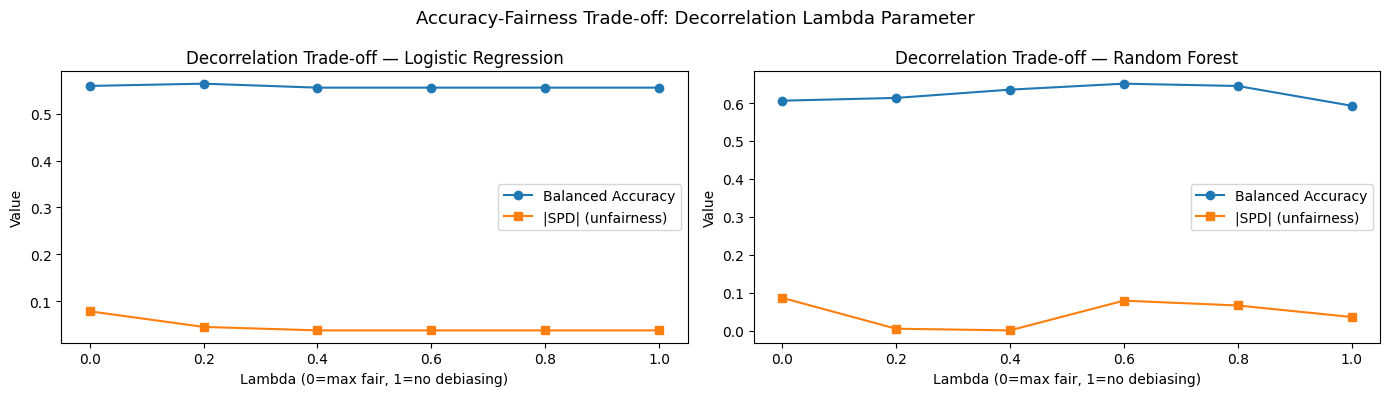

In [152]:
# Lambda trade-off plot
lambdas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
lr_accs_l, lr_spds_l = [], []
rf_accs_l, rf_spds_l = [], []

for lam in lambdas:
    Xtr_l, Xte_l = decorrelate_features(
        X_train_lr_ns, X_test_lr_ns,
        sex_train_vals, sex_test_vals, lam)
    Xtr_r, Xte_r = decorrelate_features(
        X_train_ns, X_test_ns,
        sex_train_vals, sex_test_vals, lam)

    m_l = LogisticRegression(max_iter=1000)
    m_l.fit(Xtr_l, y_train)
    p_l = m_l.predict(Xte_l)
    lr_accs_l.append(balanced_accuracy_score(y_test, p_l))
    lr_spds_l.append(abs(compute_fairness_metrics(p_l, y_test, group_test)['SPD']))

    m_r = RandomForestClassifier(n_estimators=100, random_state=0)
    m_r.fit(Xtr_r, y_train)
    p_r = m_r.predict(Xte_r)
    rf_accs_l.append(balanced_accuracy_score(y_test, p_r))
    rf_spds_l.append(abs(compute_fairness_metrics(p_r, y_test, group_test)['SPD']))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, accs, spds, title in zip(
    axes,
    [lr_accs_l, rf_accs_l],
    [lr_spds_l, rf_spds_l],
    ['Logistic Regression', 'Random Forest']
):
    ax.plot(lambdas, accs, label='Balanced Accuracy', marker='o')
    ax.plot(lambdas, spds, label='|SPD| (unfairness)', marker='s')
    ax.set_xlabel('Lambda (0=max fair, 1=no debiasing)')
    ax.set_ylabel('Value')
    ax.set_title(f'Decorrelation Trade-off — {title}')
    ax.legend()
plt.suptitle('Accuracy-Fairness Trade-off: Decorrelation Lambda Parameter', fontsize=13)
plt.tight_layout()
plt.show()

## METHOD 3: FAIR PCA

In [153]:
def fair_pca(X_train, X_test, sex_train, sex_test, k=None, lambda_param=0.0):
    """
    Fair PCA targeting STATISTICAL PARITY.
    k            = dimensions to keep (default: d-1, must be integer)
    lambda_param = 0 -> only fair PCA
                   1 -> blend with standard PCA
    """
    X_mat = X_train.copy().astype(np.float64).values
    X_tst = X_test.copy().astype(np.float64).values
    d     = X_mat.shape[1]

    if k is None:
        k = int(d - 1)
    else:
        k = int(k)

    z   = sex_train.astype(np.float64)
    z_c = z - z.mean()

    zX = (z_c @ X_mat).reshape(1, -1)
    R  = null_space(zX)

    M       = R.T @ X_mat.T @ X_mat @ R
    _, evec = eigh(M)
    Lambda  = evec[:, -k:]
    U_fair  = R @ Lambda

    Xtr_fair = X_mat @ U_fair
    Xte_fair = X_tst @ U_fair

    if lambda_param > 0:
        _, std_ev = eigh(X_mat.T @ X_mat)
        U_std     = std_ev[:, -k:]
        Xtr_fair  = np.hstack([Xtr_fair, lambda_param * (X_mat @ U_std)])
        Xte_fair  = np.hstack([Xte_fair, lambda_param * (X_tst @ U_std)])

    return Xtr_fair, Xte_fair


print('Fair PCA function defined.')
print('Note: marginal centering targets statistical parity.')

Fair PCA function defined.
Note: marginal centering targets statistical parity.


In [154]:
# Verify Fair PCA removes sex predictability
from sklearn.linear_model import LogisticRegression as LRcheck
sex_bin   = (group_train == 2).astype(int)
sex_bin_t = (group_test  == 2).astype(int)

clf_b = LRcheck(max_iter=1000).fit(X_train_lr_ns, sex_bin)

clf_a_data, clf_a_test = fair_pca(
    X_train_lr_ns, X_test_lr_ns,
    sex_train_vals, sex_test_vals,
    lambda_param=0.0)

clf_a = LRcheck(max_iter=1000).fit(clf_a_data, sex_bin)

print(f'Sex prediction acc BEFORE Fair PCA: {clf_b.score(X_test_lr_ns, sex_bin_t):.4f}')
print(f'Sex prediction acc AFTER  Fair PCA: {clf_a.score(clf_a_test, sex_bin_t):.4f}')
print(f'Majority class baseline:            {max(sex_bin_t.mean(), 1-sex_bin_t.mean()):.4f}')
print('Fair PCA working correctly if AFTER acc ≈ majority baseline')

# Apply Fair PCA for LR and RF
X_train_fpca_lr, X_test_fpca_lr = fair_pca(
    X_train_lr_ns, X_test_lr_ns,
    sex_train_vals, sex_test_vals,
    lambda_param=0.0)

X_train_fpca_rf, X_test_fpca_rf = fair_pca(
    X_train_ns, X_test_ns,
    sex_train_vals, sex_test_vals,
    lambda_param=0.0)

print(f'\nShape after Fair PCA (LR): {X_train_fpca_lr.shape}')
print(f'Shape of baseline   (LR): {X_train_lr_ns.shape}')

lr_fpca = LogisticRegression(max_iter=1000)
lr_fpca.fit(X_train_fpca_lr, y_train)
lr_fpca_preds = lr_fpca.predict(X_test_fpca_lr)

rf_fpca = RandomForestClassifier(n_estimators=100, random_state=0)
rf_fpca.fit(X_train_fpca_rf, y_train)
rf_fpca_preds = rf_fpca.predict(X_test_fpca_rf)

lr_fpca_acc     = balanced_accuracy_score(y_test, lr_fpca_preds)
rf_fpca_acc     = balanced_accuracy_score(y_test, rf_fpca_preds)
lr_fpca_metrics = compute_fairness_metrics(lr_fpca_preds, y_test, group_test)
rf_fpca_metrics = compute_fairness_metrics(rf_fpca_preds, y_test, group_test)

print('\n=== Fair PCA Results ===')
print(f'LR: acc={lr_fpca_acc:.4f}, {lr_fpca_metrics}')
print(f'RF: acc={rf_fpca_acc:.4f}, {rf_fpca_metrics}')

Sex prediction acc BEFORE Fair PCA: 0.6837
Sex prediction acc AFTER  Fair PCA: 0.6939
Majority class baseline:            0.6939
Fair PCA working correctly if AFTER acc ≈ majority baseline

Shape after Fair PCA (LR): (782, 20)
Shape of baseline   (LR): (782, 21)

=== Fair PCA Results ===
LR: acc=0.5712, {'SPD': 0.0544, 'DI': 1.0643, 'TPR_diff': 0.0251, 'FPR_diff': 0.1466}
RF: acc=0.6765, {'SPD': -0.0088, 'DI': 0.9891, 'TPR_diff': 0.0508, 'FPR_diff': -0.0551}


### SHAP: Before vs After Preprocessing

.

In [155]:
rng_post      = np.random.RandomState(1)
N_SHAP_POST   = min(200, len(y_test))
shap_idx_post = rng_post.choice(len(X_test_ns), size=N_SHAP_POST, replace=False)

rf_feature_names = list(X_train_ns.columns)
n_features       = len(rf_feature_names)
print(f"Number of features: {n_features}")

#  RF Baseline
explainer_base = shap.TreeExplainer(rf_base)
shap_base_raw  = explainer_base.shap_values(
    X_test_ns.iloc[shap_idx_post].astype(np.float64), approximate=True)

# TreeExplainer for binary classification returns [class0_array, class1_array]
# We always want class 1 (good risk = positive class)
if isinstance(shap_base_raw, list):
    shap_base = np.asarray(shap_base_raw[1], dtype=np.float64)
else:
    shap_base = np.asarray(shap_base_raw, dtype=np.float64)

# If still 2D with double columns, take first n_features columns
if shap_base.ndim == 2 and shap_base.shape[1] > n_features:
    shap_base = shap_base[:, :n_features]

print(f"shap_base shape: {shap_base.shape}  (should be ({N_SHAP_POST}, {n_features}))")

# RF Decorrelation
explainer_dec = shap.TreeExplainer(rf_dec)
shap_dec_raw  = explainer_dec.shap_values(
    X_test_dec_rf.iloc[shap_idx_post].astype(np.float64), approximate=True)

if isinstance(shap_dec_raw, list):
    shap_dec = np.asarray(shap_dec_raw[1], dtype=np.float64)
else:
    shap_dec = np.asarray(shap_dec_raw, dtype=np.float64)

if shap_dec.ndim == 2 and shap_dec.shape[1] > n_features:
    shap_dec = shap_dec[:, :n_features]

print(f"shap_dec shape:  {shap_dec.shape}  (should be ({N_SHAP_POST}, {n_features}))")

#  RF Fair PCA
# Fair PCA features are PCA components — not original features
# So we only compute global importance, not per-original-feature
explainer_fpca = shap.TreeExplainer(rf_fpca)
shap_fpca_raw  = explainer_fpca.shap_values(
    X_test_fpca_rf[shap_idx_post], approximate=True)

if isinstance(shap_fpca_raw, list):
    shap_fpca = np.asarray(shap_fpca_raw[1], dtype=np.float64)
else:
    shap_fpca = np.asarray(shap_fpca_raw, dtype=np.float64)

if shap_fpca.ndim == 2 and shap_fpca.shape[1] > (n_features - 1):
    shap_fpca = shap_fpca[:, :(n_features - 1)]

print(f"shap_fpca shape: {shap_fpca.shape}  (Fair PCA has d-1={n_features-1} components)")
print("\nAll SHAP values computed successfully.")

Number of features: 21
shap_base shape: (196, 21, 2)  (should be (196, 21))
shap_dec shape:  (196, 21, 2)  (should be (196, 21))
shap_fpca shape: (196, 20, 2)  (Fair PCA has d-1=20 components)

All SHAP values computed successfully.


=== RF Baseline — SHAP Summary ===


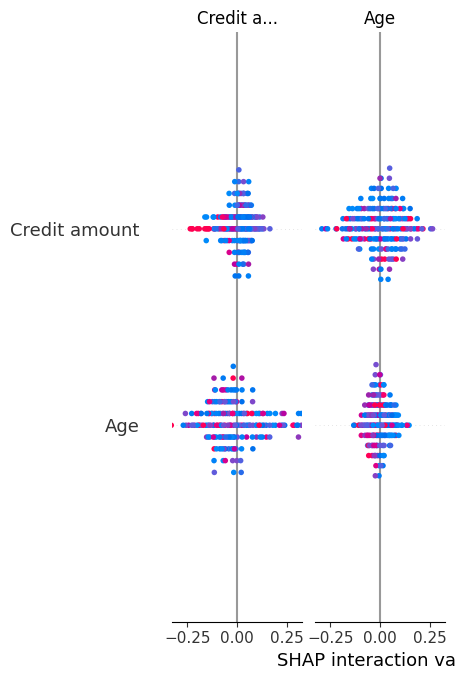

In [156]:
# SHAP Summary: RF Baseline
print('=== RF Baseline — SHAP Summary ===')
shap.summary_plot(
    shap_base,
    X_test_ns.iloc[shap_idx_post].values,
    feature_names=rf_feature_names,
    show=True,
    plot_type='dot'
)

=== RF Decorrelation — SHAP Summary ===


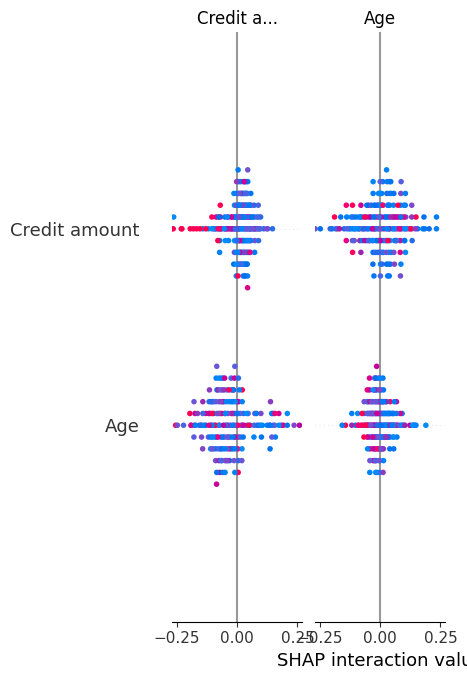


Note: feature values are continuous after decorrelation
because the sex-correlated component was subtracted from each feature.


In [157]:
# SHAP Summary: RF Decorrelation
print('=== RF Decorrelation — SHAP Summary ===')
shap.summary_plot(
    shap_dec,
    X_test_dec_rf.iloc[shap_idx_post].values,
    feature_names=rf_feature_names,
    show=True,
    plot_type='dot'
)
print('\nNote: feature values are continuous after decorrelation')
print('because the sex-correlated component was subtracted from each feature.')

shap_base_arr shape: (196, 21)
mean_base length: 21


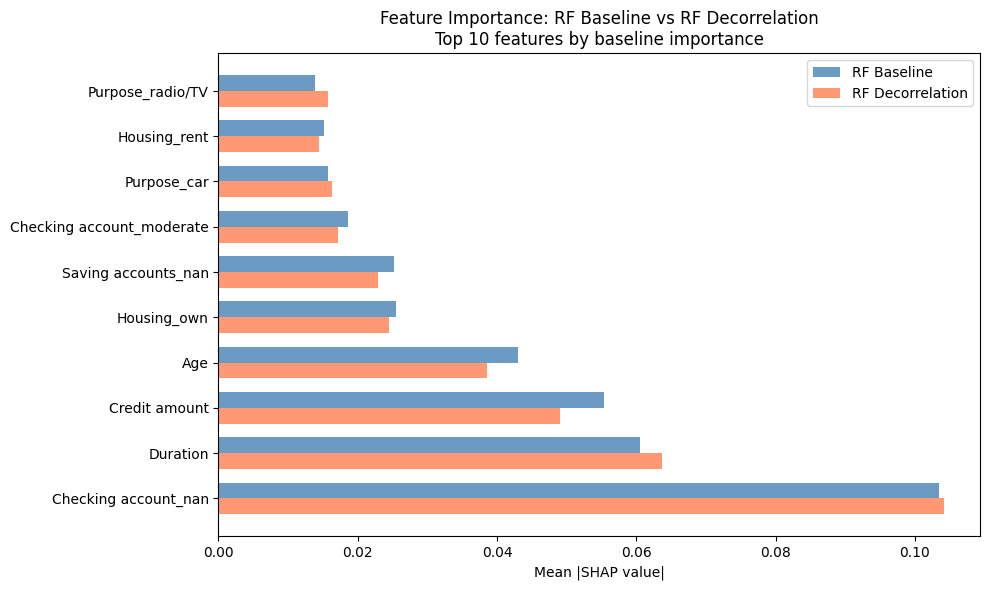


Interpretation:
Features that SHRINK after decorrelation were relying on
gender-correlated information to make predictions.
Features that GROW are picking up more of the pure credit signal.


In [158]:
# shap_base is (196, 21, 2) — take class 1 (good risk)
shap_base_arr = np.array(shap_base)[:, :, 1]
shap_dec_arr  = np.array(shap_dec)[:, :, 1]

print("shap_base_arr shape:", shap_base_arr.shape)  # should be (196, 21)

mean_base = np.abs(shap_base_arr).mean(axis=0).flatten()
mean_dec  = np.abs(shap_dec_arr).mean(axis=0).flatten()

print(f"mean_base length: {len(mean_base)}")  # should be 21

sorted_idx = np.argsort(mean_base)[::-1][:10].tolist()
fnames_top = [rf_feature_names[i] for i in sorted_idx]

x_pos = np.arange(len(sorted_idx))
w     = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(x_pos + w/2, [mean_base[i] for i in sorted_idx],
        w, color='steelblue', alpha=0.8, label='RF Baseline')
ax.barh(x_pos - w/2, [mean_dec[i]  for i in sorted_idx],
        w, color='coral',     alpha=0.8, label='RF Decorrelation')
ax.set_yticks(x_pos)
ax.set_yticklabels(fnames_top)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance: RF Baseline vs RF Decorrelation\n'
             'Top 10 features by baseline importance', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('Features that SHRINK after decorrelation were relying on')
print('gender-correlated information to make predictions.')
print('Features that GROW are picking up more of the pure credit signal.')

Male in SHAP sample:   136
Female in SHAP sample: 60


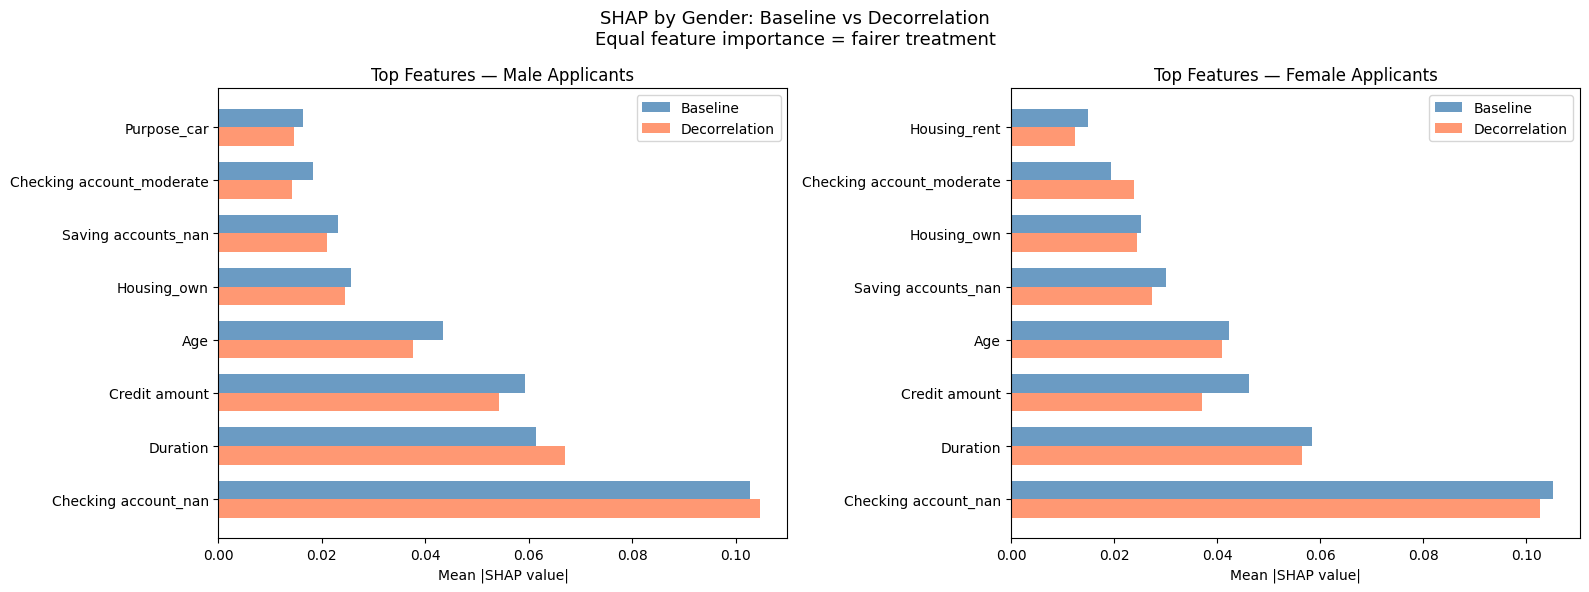


If the same features matter equally for men and women,
the model is applying consistent criteria across genders.


In [159]:
#  SHAP by Gender: Does model treat groups differently?

# Handle 3D shape (n_samples, n_features, n_classes)
shap_base_arr = np.array(shap_base)
if shap_base_arr.ndim == 3:
    shap_base_arr = shap_base_arr[:, :, 1]

shap_dec_arr = np.array(shap_dec)
if shap_dec_arr.ndim == 3:
    shap_dec_arr = shap_dec_arr[:, :, 1]

group_shap_post = group_test[shap_idx_post]
male_m          = group_shap_post == 1
female_m        = group_shap_post == 2

print(f'Male in SHAP sample:   {male_m.sum()}')
print(f'Female in SHAP sample: {female_m.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, mask, gender in zip(
    axes,
    [male_m,  female_m],
    ['Male',  'Female']
):
    mean_g_base = np.abs(shap_base_arr[mask]).mean(axis=0).flatten()
    mean_g_dec  = np.abs(shap_dec_arr[mask]).mean(axis=0).flatten()

    top_idx   = np.argsort(mean_g_base)[::-1][:8].tolist()
    top_names = [rf_feature_names[i] for i in top_idx]

    x_pos = np.arange(len(top_idx))
    w     = 0.35

    ax.barh(x_pos + w/2, [mean_g_base[i] for i in top_idx],
            w, color='steelblue', alpha=0.8, label='Baseline')
    ax.barh(x_pos - w/2, [mean_g_dec[i]  for i in top_idx],
            w, color='coral',     alpha=0.8, label='Decorrelation')
    ax.set_yticks(x_pos)
    ax.set_yticklabels(top_names)
    ax.set_title(f'Top Features — {gender} Applicants', fontsize=12)
    ax.set_xlabel('Mean |SHAP value|')
    ax.legend()

plt.suptitle('SHAP by Gender: Baseline vs Decorrelation\n'
             'Equal feature importance = fairer treatment', fontsize=13)
plt.tight_layout()
plt.show()

print('\nIf the same features matter equally for men and women,')
print('the model is applying consistent criteria across genders.')

In [160]:
#  Proxy Feature Contribution: Before vs After

# Handle 3D shape
shap_base_arr = np.array(shap_base)
if shap_base_arr.ndim == 3:
    shap_base_arr = shap_base_arr[:, :, 1]

shap_dec_arr = np.array(shap_dec)
if shap_dec_arr.ndim == 3:
    shap_dec_arr = shap_dec_arr[:, :, 1]

mean_base = np.abs(shap_base_arr).mean(axis=0).flatten()
mean_dec  = np.abs(shap_dec_arr).mean(axis=0).flatten()

proxy_features = [
    'Housing_rent',
    'Age',
    'Purpose_furniture/equipment',
    'Housing_own',
    'Credit amount',
    'Duration'
]

print('=== Proxy Feature SHAP: Baseline vs Decorrelation ===')
print(f'{"Feature":35s}  Baseline   Decorrel   Change')
print('-' * 65)

for feat in proxy_features:
    if feat in rf_feature_names:
        idx      = rf_feature_names.index(feat)
        base_val = float(mean_base[idx])
        dec_val  = float(mean_dec[idx])
        change   = dec_val - base_val
        arrow    = '↑' if change > 0 else '↓'
        print(f'{feat:35s}  {base_val:.4f}     {dec_val:.4f}   '
              f'{change:+.4f} {arrow}')

print()
print('Features that DECREASED were using sex-correlated information.')
print('These are the proxy features from Lecture 5.')
print('Features that INCREASED now do more work explaining credit risk.')

=== Proxy Feature SHAP: Baseline vs Decorrelation ===
Feature                              Baseline   Decorrel   Change
-----------------------------------------------------------------
Housing_rent                         0.0152     0.0145   -0.0007 ↓
Age                                  0.0431     0.0386   -0.0045 ↓
Purpose_furniture/equipment          0.0095     0.0100   +0.0004 ↑
Housing_own                          0.0256     0.0245   -0.0011 ↓
Credit amount                        0.0553     0.0490   -0.0063 ↓
Duration                             0.0605     0.0638   +0.0032 ↑

Features that DECREASED were using sex-correlated information.
These are the proxy features from Lecture 5.
Features that INCREASED now do more work explaining credit risk.


## Why Does Decorrelation Have No Effect on LR?

=== LR Regularization + Decorrelation ===
Lower C = stronger regularization = less compensation possible

C= 1.000: acc=0.5591, SPD=+0.0784, |SPD|=0.0784
C= 0.500: acc=0.5506, SPD=+0.0711, |SPD|=0.0711
C= 0.100: acc=0.5410, SPD=+0.0897, |SPD|=0.0897
C= 0.050: acc=0.5349, SPD=+0.0529, |SPD|=0.0529
C= 0.010: acc=0.5229, SPD=+0.0034, |SPD|=0.0034
C= 0.001: acc=0.5000, SPD=+0.0000, |SPD|=0.0000


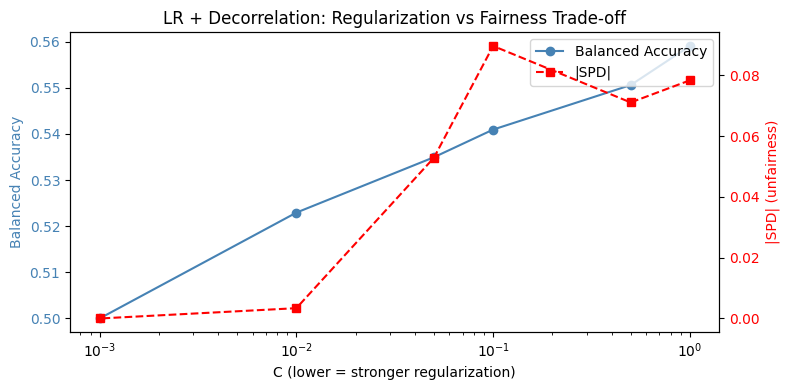


Conclusion: if stronger regularization reduces |SPD|, it confirms that
LR was compensating for decorrelation through feature weight combinations.


In [161]:
# LR Regularization analysis after decorrelation
print('=== LR Regularization + Decorrelation ===')
print('Lower C = stronger regularization = less compensation possible')
print()

reg_results = []
for C in [1.0, 0.5, 0.1, 0.05, 0.01, 0.001]:
    lr_reg = LogisticRegression(max_iter=1000, C=C)
    lr_reg.fit(X_train_dec_lr, y_train)
    preds = lr_reg.predict(X_test_dec_lr)
    acc   = balanced_accuracy_score(y_test, preds)
    m     = compute_fairness_metrics(preds, y_test, group_test)
    reg_results.append({'C': C, 'acc': acc, 'spd': m['SPD'], 'abs_spd': abs(m['SPD'])})
    print(f'C={C:6.3f}: acc={acc:.4f}, SPD={m["SPD"]:+.4f}, |SPD|={abs(m["SPD"]):.4f}')

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
Cs   = [r['C']       for r in reg_results]
accs = [r['acc']     for r in reg_results]
spds = [r['abs_spd'] for r in reg_results]

ax1.semilogx(Cs, accs, 'o-', color='steelblue', label='Balanced Accuracy')
ax1.set_xlabel('C (lower = stronger regularization)')
ax1.set_ylabel('Balanced Accuracy', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.semilogx(Cs, spds, 's--', color='red', label='|SPD|')
ax2.set_ylabel('|SPD| (unfairness)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('LR + Decorrelation: Regularization vs Fairness Trade-off')
plt.tight_layout()
plt.show()

print('\nConclusion: if stronger regularization reduces |SPD|, it confirms that')
print('LR was compensating for decorrelation through feature weight combinations.')

## Prediction Rate Diagnostic

In [162]:
print('=== Prediction Rates by Gender — All Methods ===')
print(f'{"Method":28s} male   female   diff')
print('-' * 55)
for name, preds in [
    ('LR Baseline',       lr_base_preds),
    ('LR Reweighing',     lr_rw_preds),
    ('LR Decorrelation',  lr_dec_preds),
    ('LR Fair PCA',       lr_fpca_preds),
    ('RF Baseline',       rf_base_preds),
    ('RF Reweighing',     rf_rw_preds),
    ('RF Decorrelation',  rf_dec_preds),
    ('RF Fair PCA',       rf_fpca_preds),
]:
    m = np.mean(preds[group_test == 1])
    f = np.mean(preds[group_test == 2])
    print(f'{name:28s} {m:.3f}  {f:.3f}   {f-m:+.3f}')

=== Prediction Rates by Gender — All Methods ===
Method                       male   female   diff
-------------------------------------------------------
LR Baseline                  0.846  0.883   +0.038
LR Reweighing                0.838  0.883   +0.045
LR Decorrelation             0.838  0.917   +0.078
LR Fair PCA                  0.846  0.900   +0.054
RF Baseline                  0.838  0.867   +0.028
RF Reweighing                0.824  0.833   +0.010
RF Decorrelation             0.853  0.767   -0.086
RF Fair PCA                  0.809  0.800   -0.009


##  FINAL COMPARISON TABLE

In [163]:
results = pd.DataFrame({
    'Method': ['Baseline','Baseline','Reweighing','Reweighing',
               'Decorrelation','Decorrelation','Fair PCA','Fair PCA'],
    'Model':  ['LR','RF'] * 4,
    'Balanced Acc': [lr_base_acc, rf_base_acc, lr_rw_acc, rf_rw_acc,
                     lr_dec_acc,  rf_dec_acc,  lr_fpca_acc, rf_fpca_acc],
    'SPD':      [lr_base_metrics['SPD'],  rf_base_metrics['SPD'],
                 lr_rw_metrics['SPD'],    rf_rw_metrics['SPD'],
                 lr_dec_metrics['SPD'],   rf_dec_metrics['SPD'],
                 lr_fpca_metrics['SPD'],  rf_fpca_metrics['SPD']],
    'DI':       [lr_base_metrics['DI'],   rf_base_metrics['DI'],
                 lr_rw_metrics['DI'],     rf_rw_metrics['DI'],
                 lr_dec_metrics['DI'],    rf_dec_metrics['DI'],
                 lr_fpca_metrics['DI'],   rf_fpca_metrics['DI']],
    'TPR_diff': [lr_base_metrics['TPR_diff'], rf_base_metrics['TPR_diff'],
                 lr_rw_metrics['TPR_diff'],   rf_rw_metrics['TPR_diff'],
                 lr_dec_metrics['TPR_diff'],  rf_dec_metrics['TPR_diff'],
                 lr_fpca_metrics['TPR_diff'], rf_fpca_metrics['TPR_diff']],
    'FPR_diff': [lr_base_metrics['FPR_diff'], rf_base_metrics['FPR_diff'],
                 lr_rw_metrics['FPR_diff'],   rf_rw_metrics['FPR_diff'],
                 lr_dec_metrics['FPR_diff'],  rf_dec_metrics['FPR_diff'],
                 lr_fpca_metrics['FPR_diff'], rf_fpca_metrics['FPR_diff']]
})

print('=== FULL COMPARISON TABLE ===')
print(results.to_string(index=False))

=== FULL COMPARISON TABLE ===
       Method Model  Balanced Acc     SPD     DI  TPR_diff  FPR_diff
     Baseline    LR      0.555425  0.0377 1.0446    0.0455    0.0464
     Baseline    RF      0.596623  0.0284 1.0339    0.0610    0.0038
   Reweighing    LR      0.563900  0.0451 1.0538    0.0455    0.0727
   Reweighing    RF      0.618397  0.0098 1.0119    0.0712   -0.0652
Decorrelation    LR      0.559075  0.0784 1.0936    0.0712    0.1203
Decorrelation    RF      0.606272 -0.0863 0.8989    0.0097   -0.2393
     Fair PCA    LR      0.571199  0.0544 1.0643    0.0251    0.1466
     Fair PCA    RF      0.676543 -0.0088 0.9891    0.0508   -0.0551


## PARETO FRONTIER PLOT

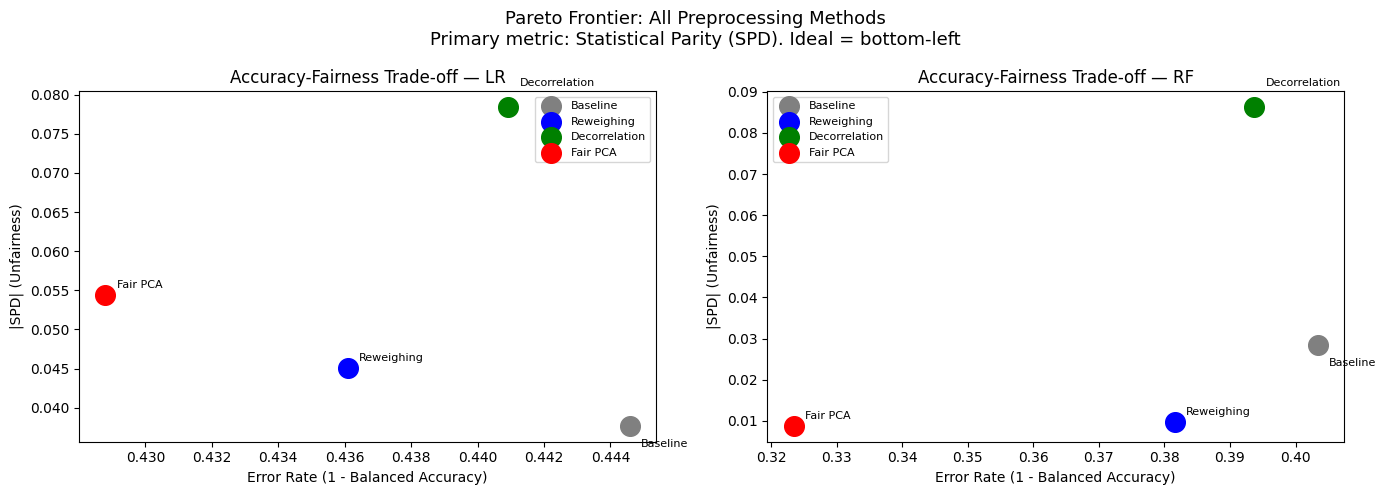

In [164]:
# Pareto Frontier — SPD as primary fairness metric
methods = ['Baseline', 'Reweighing', 'Decorrelation', 'Fair PCA']
colors  = ['gray', 'blue', 'green', 'red']
offsets = {'Baseline':(8,-15), 'Reweighing':(8,5), 'Decorrelation':(8,15), 'Fair PCA':(8,5)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mt in zip(axes, ['LR', 'RF']):
    sub = results[results['Model'] == mt].reset_index(drop=True)
    for i, row in sub.iterrows():
        ax.scatter(1-row['Balanced Acc'], abs(row['SPD']),
                   color=colors[i], s=200, zorder=5, label=row['Method'])
        ax.annotate(row['Method'],
                    (1-row['Balanced Acc'], abs(row['SPD'])),
                    textcoords='offset points',
                    xytext=offsets.get(row['Method'], (8,5)), fontsize=8)
    ax.set_xlabel('Error Rate (1 - Balanced Accuracy)')
    ax.set_ylabel('|SPD| (Unfairness)')
    ax.set_title(f'Accuracy-Fairness Trade-off — {mt}')
    ax.legend(fontsize=8)

plt.suptitle('Pareto Frontier: All Preprocessing Methods\n'
             'Primary metric: Statistical Parity (SPD). Ideal = bottom-left', fontsize=13)
plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

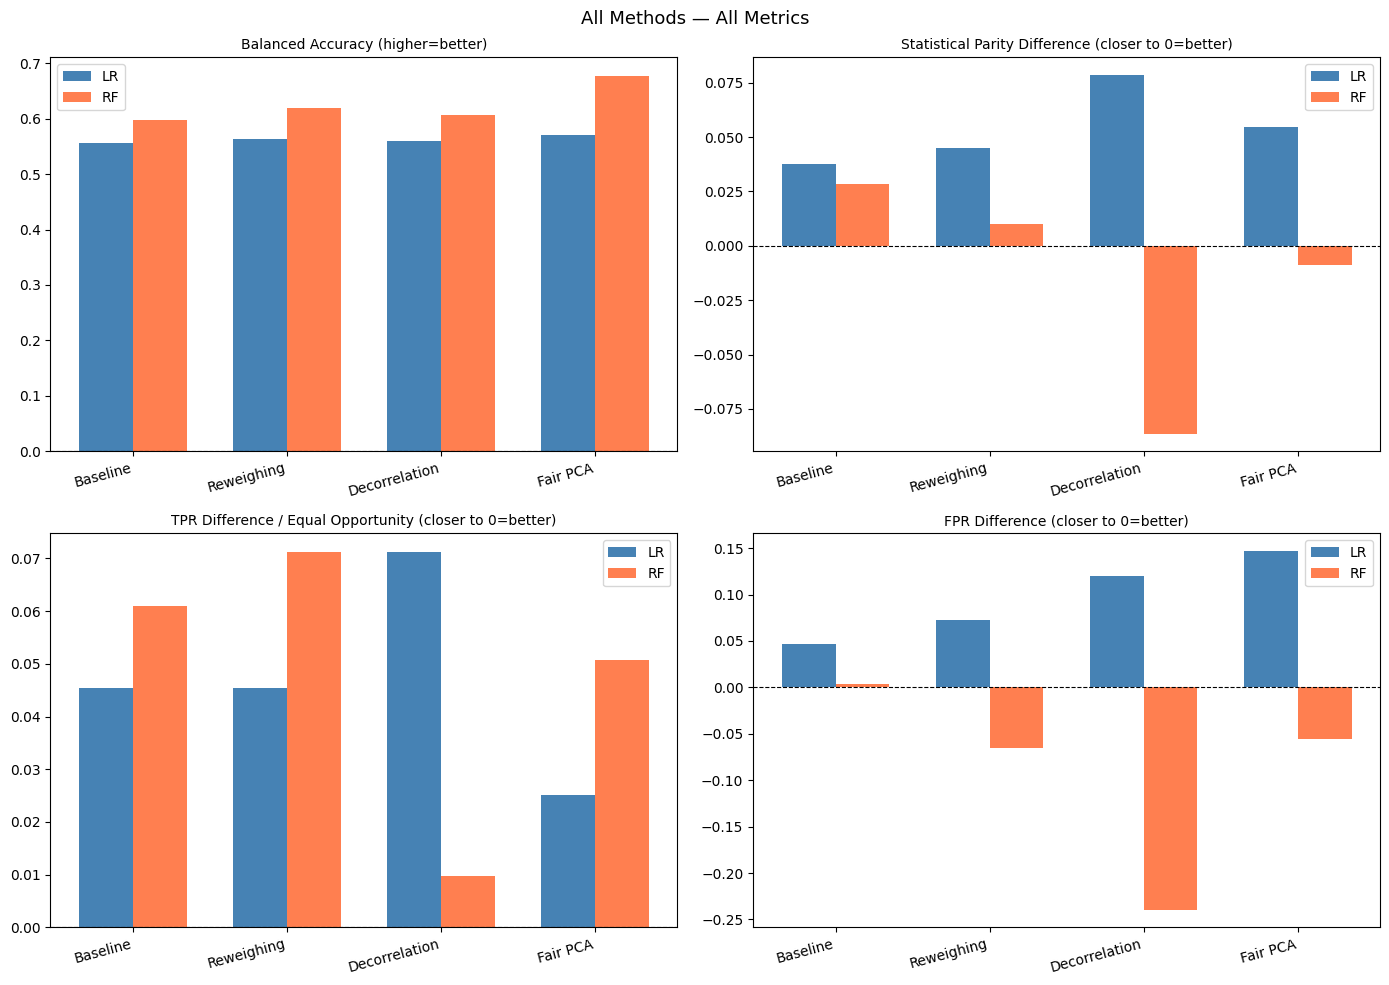

In [165]:
# Bar charts all metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_list = ['Balanced Acc', 'SPD', 'TPR_diff', 'FPR_diff']
titles_list  = [
    'Balanced Accuracy (higher=better)',
    'Statistical Parity Difference (closer to 0=better)',
    'TPR Difference / Equal Opportunity (closer to 0=better)',
    'FPR Difference (closer to 0=better)'
]
x     = np.arange(len(methods))
width = 0.35

for ax, metric, title in zip(axes.flatten(), metrics_list, titles_list):
    lr_v = results[results['Model']=='LR'][metric].values
    rf_v = results[results['Model']=='RF'][metric].values
    ax.bar(x-width/2, lr_v, width, label='LR', color='steelblue')
    ax.bar(x+width/2, rf_v, width, label='RF', color='coral')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['Baseline','Reweighing','Decorrelation','Fair PCA'],
                       rotation=15, ha='right')
    ax.set_title(title, fontsize=10)
    ax.legend()

plt.suptitle('All Methods — All Metrics', fontsize=13)
plt.tight_layout()
plt.show()

##  Summary and Interpretation


In [167]:
prev_sex_full = df.groupby('Sex')['y'].mean()
diff_full = (prev_sex_full['male'] - prev_sex_full['female']) * 100

print('=== SUMMARY ===')
print()
print('PRIMARY FAIRNESS CRITERION: STATISTICAL PARITY (SPD)')
print('Justification: The 7.48% raw label gap reflects historical structural')
print('inequality rather than genuine creditworthiness differences.')
print('Labels carry historical bias — conditioning on them (as equalized odds')
print('requires) perpetuates injustice. SPD targets equal approval rates')
print('regardless of historically biased labels. (Barocas & Selbst, 2016)')
print()
print('1. INITIAL BIAS IN DATA')
print(f'   Males are {diff_full:.2f}% more likely to be labeled good risk than females.')
print()
print('2. BIAS PERSISTS WITHOUT SEX FEATURE')
print(f'   LR baseline |SPD| = {abs(lr_base_metrics["SPD"]):.4f}')
print(f'   RF baseline |SPD| = {abs(rf_base_metrics["SPD"]):.4f}')
print('   Simply removing Sex_2 is not enough.')
print('   Gender bias flows through proxy features (housing, age, purpose etc.).')
print('   This is the proxy problem described in Barocas & Selbst (2016).')
print()
print('3. PREPROCESSING RESULTS (primary: |SPD|, secondary: |TPR_diff|)')
for name, acc, m in [
    ('LR Baseline',      lr_base_acc,  lr_base_metrics),
    ('LR Reweighing',    lr_rw_acc,    lr_rw_metrics),
    ('LR Decorrelation', lr_dec_acc,   lr_dec_metrics),
    ('LR Fair PCA',      lr_fpca_acc,  lr_fpca_metrics),
    ('RF Baseline',      rf_base_acc,  rf_base_metrics),
    ('RF Reweighing',    rf_rw_acc,    rf_rw_metrics),
    ('RF Decorrelation', rf_dec_acc,   rf_dec_metrics),
    ('RF Fair PCA',      rf_fpca_acc,  rf_fpca_metrics),
]:
    print(f'   {name:25s}: acc={acc:.3f}, |SPD|={abs(m["SPD"]):.3f}, |TPR_diff|={abs(m["TPR_diff"]):.3f}')
print()
print('4. KEY LIMITATIONS')
print('   - Labels may encode historical discrimination (Barocas & Selbst, 2016)')
print('   - Decorrelation and Fair PCA only remove LINEAR correlations')
print('   - Non-linear proxy relationships may remain')
print('   - Small female test set (~60 instances) makes FPR_diff metrics noisy')
print('   - Results may differ on other random seeds / splits')
print()
print('5. FAIRNESS IMPOSSIBILITY (Kleinberg et al., 2016)')
print('   No single method satisfies all fairness criteria simultaneously.')
print(f'   RF Reweighing:    |SPD|={abs(rf_rw_metrics["SPD"]):.3f} but |TPR_diff|={abs(rf_rw_metrics["TPR_diff"]):.3f}')
print(f'   RF Decorrelation: |SPD|={abs(rf_dec_metrics["SPD"]):.3f} but |TPR_diff|={abs(rf_dec_metrics["TPR_diff"]):.3f}')
print('   Improving SPD tends to worsen TPR_diff and vice versa.')
print('   This is a mathematical inevitability when base rates differ across groups.')

=== SUMMARY ===

PRIMARY FAIRNESS CRITERION: STATISTICAL PARITY (SPD)
Justification: The 7.48% raw label gap reflects historical structural
inequality rather than genuine creditworthiness differences.
Labels carry historical bias — conditioning on them (as equalized odds
requires) perpetuates injustice. SPD targets equal approval rates
regardless of historically biased labels. (Barocas & Selbst, 2016)

1. INITIAL BIAS IN DATA
   Males are 7.48% more likely to be labeled good risk than females.

2. BIAS PERSISTS WITHOUT SEX FEATURE
   LR baseline |SPD| = 0.0377
   RF baseline |SPD| = 0.0284
   Simply removing Sex_2 is not enough.
   Gender bias flows through proxy features (housing, age, purpose etc.).
   This is the proxy problem described in Barocas & Selbst (2016).

3. PREPROCESSING RESULTS (primary: |SPD|, secondary: |TPR_diff|)
   LR Baseline              : acc=0.555, |SPD|=0.038, |TPR_diff|=0.045
   LR Reweighing            : acc=0.564, |SPD|=0.045, |TPR_diff|=0.045
   LR Decorrel